# Triage Gaps in U.S. Emergency Departments
A descriptive study of NHAMCS 2022 immediacy levels (IMMEDR 1-5)

Every model below is used as a measuring instrument to describe how triage actually behaves, so that a clinician can read off what to look out for at each acuity level.

Mean wait by IMMEDR is an inverted U(24.9, 28.5, 37.6, 35.5, 30.8 min for levels 1→5), and the gap versus CTAS targetsflips sign at the 3/4 boundary: only levels 1–3 run over target, and the coverage is largest for the sickest patients (level 1: +24.9 min against a 0-minute target).

## Section 0: Setup Imports and configuration

In [1]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 3.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4120 sha256=a519276bed98164b7021a776569b416308e6d44c2209534ad5546f3809b35456
  Stored in directory: /root/.cache/pip/wheels/7e/16/46/9477f188924292d3bf1fb8fb42844201591abfc19b7ba6d868
Successfully built autograd-gamma


In [82]:
# imports, dependency guard, and plot styleimport sys, subprocess, warnings, itertools, mathwarnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import Patch
import itertools
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import SplineTransformer, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.covariance import MinCovDet
from sklearn.covariance import LedoitWolf
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.miscmodels.ordinal_model import OrderedModel
# lifelines is optional: used only for the log-rank test. Kaplan-Meier is hand-rolled
# below so the notebook never hard-fails on a missing package.
try:
  from lifelines.statistics import logrank_test
  HAS_LIFELINES = True
except ImportError:
  HAS_LIFELINES = False
  print("lifelines not found; log-rank test will be skipped. "
        "Run `!pip install lifelines` to enable it.")
plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.labelsize': 10, 'font.family': 'DejaVu Sans',})

print("\nImports OK")


Imports OK


In [ ]:
# config - every tunable, clinical constant, and analysis switch in the project

#  data
DATA_PATH    = 'ed2022-stata.dta'   # NHAMCS 2022 ED public use file (Stata)
RANDOM_STATE = 42

# the acuity scale
IMMEDR_LEVELS = [1, 2, 3, 4, 5]
IMMEDR_LABELS = {1: '1 Immediate', 2: '2 Emergent', 3: '3 Urgent',
                 4: '4 Semi-urgent', 5: '5 Non-urgent'}
IMMEDR_COLORS = ['#B3202C', '#E07B39', '#E8C547', '#3D9970', '#2E75B6']
IMMEDR_CMAP   = dict(zip(IMMEDR_LEVELS, IMMEDR_COLORS))
ADJACENT_PAIRS = [(1, 2), (2, 3), (3, 4), (4, 5)]   # boundary analyses

#  clinical reference standard (CTAS) time-to-physician targets, minutes
TARGET_MINUTES = {1: 0, 2: 15, 3: 30, 4: 60, 5: 120}

# CTAS "fractile response" goals: share of each level that SHOULD meet the target.
FRACTILE_TARGETS = {1: 0.98, 2: 0.95, 3: 0.90, 4: 0.85, 5: 0.80}

# Alternatives, swap in for sensitivity analysis:
#   Australasian Triage Scale (ATS): {1:0, 2:10, 3:30, 4:60,  5:120}
#   Manchester Triage System (MTS):  {1:0, 2:10, 3:60, 4:120, 5:240}
ALT_TARGETS = {'ATS': {1:0, 2:10, 3:30, 4:60, 5:120},
               'MTS': {1:0, 2:10, 3:60, 4:120, 5:240}}

# Counterfactual: redistribute the OBSERVED total wait budget strictly by urgency.
SEVERITY_WEIGHTS = {1: 5, 2: 4, 3: 3, 4: 2, 5: 1}
PRESERVE_TOTAL_WAIT_BUDGET = True

# statistical policy
# NCHS advises testing the 2022 NHAMCS ED file at alpha=0.01, not 0.05, because of
# elevated error in the final survey year
FDR_ALPHA    = 0.01
N_BOOTSTRAP  = 1000          # raise to 2000+ for the final paper run
BOOT_SEED    = 7
MIN_CELL_N   = 30            # below this, report the count and suppress the estimate

# survey design
SURVEY_WEIGHT_COL = 'PATWT'    # patient visit weight
STRATUM_COL       = 'CSTRATM'  # masked stratum
PSU_COL           = 'CPSUM'    # masked primary sampling unit
HOSPID_CANDIDATES = ['HOSPCODE', 'CPSUM']   # first one present is used as "hospital"

# NHAMCS missing-value codes
# The 2022 file uses negative sentinels for blank/unknown/not-applicable.
NEGATIVE_SENTINELS = [-9, -8, -7, -6, -5]

# Column-specific positive sentinels
EXTRA_SENTINELS = {'PULSE': [998], 'BPSYS': [998], 'BPDIAS': [998],
                   'PAINSCALE': [98, 99]}

# TOP-CODED
TOP_CODED = {'AGE': 94}

# physiologic plausibility bounds (values outside -> NaN, counted)
VITAL_BOUNDS = {'PULSE': (20, 300), 'RESPR': (4, 80), 'TEMPF': (80, 112),
                'BPSYS': (40, 300), 'BPDIAS': (10, 200), 'POPCT': (50, 100),
                'PAINSCALE': (0, 10), 'WAITTIME': (0, 1440), 'LOV': (0, 4320)}

# Age-specific normal ranges for abnormality flags (pulse/resp vary hugely by age)
AGE_VITAL_NORMS = {
    (0,  1):   {'PULSE': (107, 181), 'RESPR': (26, 57)},
    (1,  5):   {'PULSE': (89,  152), 'RESPR': (20, 42)},
    (5, 12):   {'PULSE': (70,  130), 'RESPR': (16, 30)},
    (12, 18):  {'PULSE': (60,  120), 'RESPR': (12, 24)},
    (18, 200): {'PULSE': (60,  100), 'RESPR': (12, 20)},
}

ADULT_BP_NORMS = {'BPSYS': (90, 140), 'BPDIAS': (60, 90)}
FEVER_F = 100.4

#  time
TIME_OF_DAY_BINS   = [-0.1, 6, 12, 18, 24]
TIME_OF_DAY_LABELS = ['Night 00-06', 'Morning 06-12', 'Afternoon 12-18', 'Evening 18-24']
USE_VMONTH = False

#  demographics
SEX_MAP      = {1: 'Female', 2: 'Male'}
RACERETH_MAP = {1: 'NH White', 2: 'NH Black', 3: 'Hispanic',
                4: 'NH Asian', 5: 'NH Other', 6: 'NH Other'}
PAYTYPER_MAP = {1: 'Private', 2: 'Medicare', 3: 'Medicaid', 4: 'Worker comp',
                5: 'Self-pay', 6: 'No charge', 7: 'Other', -9: 'Unknown'}

AGE_BINS   = [0, 1, 5, 15, 25, 45, 65, 75, 200]
AGE_LABELS = ['<1', '1-4', '5-14', '15-24', '25-44', '45-64', '65-74', '75+']

#  column groups
VITALS      = ['PULSE', 'RESPR', 'TEMPF', 'BPSYS', 'BPDIAS', 'POPCT']
PROVIDER_COLS = ['ATTPHYS', 'RESINT', 'CONSULT', 'RNLPN', 'NURSEPR', 'PHYSASST']
LWBS_COLS     = ['LEFTBTRI', 'LEFTATRI', 'LEFTAMA']

# analysis switches
RUN_SLOW_CELLS = True     # ICC / bootstrap / discordance
N_SPLINE_KNOTS = 5

np.random.seed(RANDOM_STATE)

print("Config loaded.")
print(f"  acuity levels      : {IMMEDR_LEVELS}")
print(f"  CTAS targets (min) : {TARGET_MINUTES}")
print(f"  alpha              : {FDR_ALPHA}")
print(f"  bootstrap draws    : {N_BOOTSTRAP}")
print(f"  VMONTH used        : {USE_VMONTH}  (NCHS: no seasonal estimates for 2022)")

Config loaded.
  acuity levels      : [1, 2, 3, 4, 5]
  CTAS targets (min) : {1: 0, 2: 15, 3: 30, 4: 60, 5: 120}
  alpha              : 0.01  (NCHS guidance for 2022 ED file)
  bootstrap draws    : 1000
  VMONTH used        : False  (NCHS: no seasonal estimates for 2022)


## Section 1: Cleaning

1. Sentinel sweep: NHAMCS 2022 uses negative codes for blank/unknown. We sweep systematically and report what changed.

2. The IMMEDR exclusion: ~36% of visits have no usable immediacy level. We quantify who is lost.

3. Plausibility bounds: Wide bounds that remove transcription impossibilities only.

In [ ]:
# load the NHAMCS 2022 ED public use file and confirm the survey design columns

df_raw = pd.read_stata(DATA_PATH, convert_categoricals=False)
print(f"Loaded {df_raw.shape[0]:,} visit records x {df_raw.shape[1]} columns\n")

# Which of the columns this analysis depends on actually survived into 2022?
NEEDED = {
    'core'     : ['IMMEDR', 'WAITTIME', 'LOV', 'AGE', 'SEX', 'RACERETH', 'ARRTIME', 'VDAYR'],
    'vitals'   : VITALS + ['PAINSCALE'],
    'design'   : [SURVEY_WEIGHT_COL, STRATUM_COL, PSU_COL, 'HOSPCODE', 'EDWT'],
    'provider' : PROVIDER_COLS,
    'lwbs'     : LWBS_COLS,
    'crowding' : [ 'OBSSTAY', 'ARREMS', 'AMBTRANSFER'],
    'context'  : ['SEEN72', 'INJURY', 'RFV1', 'RFV2', 'RFV3', 'DIAG1',
                  'PAYTYPER', 'RACEUN', 'ETHUN', 'REGION', 'URBAN']}
audit = []
for grp, cols in NEEDED.items():
    for c in cols:
        audit.append({'group': grp, 'column': c, 'present': c in df_raw.columns})
audit = pd.DataFrame(audit)

print("\nMissing columns:", audit.loc[~audit['present'], 'column'].tolist() or "none")

# Resolve the hospital identifier once, here.
HOSPID = next((c for c in HOSPID_CANDIDATES if c in df_raw.columns), None)
print(f"\nHospital identifier in use : {HOSPID}")
if HOSPID:
    print(f"  distinct hospitals/PSUs  : {df_raw[HOSPID].nunique():,}")
    print(f"  median visits per unit   : {df_raw.groupby(HOSPID).size().median():.0f}")

Loaded 16,025 visit records x 913 columns

COLUMN AVAILABILITY - anything False below disables the analysis that needs it
present   False  True 
group                 
context       1     10
core          0      8
crowding      0      3
design        0      5
lwbs          2      1
provider      0      6
vitals        0      7

Missing columns: ['LEFTBTRI', 'LEFTATRI', 'URBAN']

Hospital identifier in use : HOSPCODE
  distinct hospitals/PSUs  : 188
  median visits per unit   : 93


In [ ]:
# systematic negative-sentinel sweep and top-coding audit

df = df_raw.copy()

if 'TEMPF' in df.columns and df['TEMPF'].median(skipna=True) > 200:
    df['TEMPF'] = df['TEMPF'] / 10.0

# top-coding
for col, code in TOP_CODED.items():
    if col in df.columns:
        n_top = int((df[col] == code).sum())
        df[f'{col}_TOPCODED'] = (df[col] == code).astype(int)

#sweep negative sentinels across every numeric analysis column
sweep_cols = [c for c in (['WAITTIME', 'LOV', 'AGE', 'PAINSCALE'] + VITALS +
                          PROVIDER_COLS + LWBS_COLS +
                          [ 'SEEN72', 'INJURY', 'PAYTYPER', 'ARREMS'])
              if c in df.columns]

sentinel_report = []
for c in sweep_cols:
    s = pd.to_numeric(df[c], errors='coerce')
    hits = {v: int((s == v).sum()) for v in NEGATIVE_SENTINELS if (s == v).any()}
    for v in EXTRA_SENTINELS.get(c, []):
        if (s == v).any():
            hits[v] = int((s == v).sum())
    if hits:
        before = s.notna().sum()
        s = s.mask(s.isin(list(hits)))
        sentinel_report.append({'column': c, 'codes': str(sorted(hits)),
                                'n_converted': sum(hits.values()),
                                'pct_of_file': round(sum(hits.values())/len(df)*100, 1),
                                'valid_after': int(s.notna().sum()),
                                'valid_before': int(before)})
    df[c] = s

rep = pd.DataFrame(sentinel_report).sort_values('pct_of_file', ascending=False)
print("\nSENTINEL SWEEP (codes converted to NaN)")
print(rep.to_string(index=False) if len(rep) else "  (no sentinels found)")

TEMPF rescaled from tenths-of-a-degree to degrees F
Top-coded AGE == 94: 100 records kept and flagged (0.6%)  (NOT treated as missing)

SENTINEL SWEEP - codes converted to NaN
   column     codes  n_converted  pct_of_file  valid_after  valid_before
PAINSCALE  [-9, -8]         7055         44.0         8970         16025
 WAITTIME  [-9, -7]         2753         17.2        13272         16025
   BPDIAS [-9, 998]         1754         10.9        14271         16025
 PAYTYPER  [-9, -8]         1737         10.8        14288         16025
   SEEN72  [-9, -8]         1717         10.7        14308         16025
    BPSYS      [-9]         1722         10.7        14303         16025
    PULSE [-9, 998]         1053          6.6        14972         16025
   INJURY  [-9, -8]          995          6.2        15030         16025
    POPCT      [-9]          969          6.0        15056         16025
    RESPR      [-9]          856          5.3        15169         16025
      LOV      [-9]  

RAW IMMEDR value counts (before any filtering)
IMMEDR
-9     364
-8    3788
 0     587
 1     139
 2    1595
 3    5340
 4    2826
 5     307
 7    1079

Retained : 10,207 (63.7%)
Dropped  : 5,818 (36.3%)

DROPPED vs RETAINED - standardized mean differences
   column  retained_mean  dropped_mean    SMD  retained_pct_missing  dropped_pct_missing
    TEMPF          95.33         87.44 -0.317                   0.0                  0.0
    BPSYS         135.49        132.02 -0.143                   8.1                 15.4
PAINSCALE           4.49          4.92  0.115                  29.2                 70.0
   BPDIAS          79.64         78.10 -0.104                   8.3                 15.6
      AGE          41.07         38.85 -0.089                   0.0                  0.0
    RESPR          19.65         20.17  0.078                   2.3                 10.6
   INJURY           0.35          0.31 -0.072                   3.9                 10.3
    POPCT          97.38      

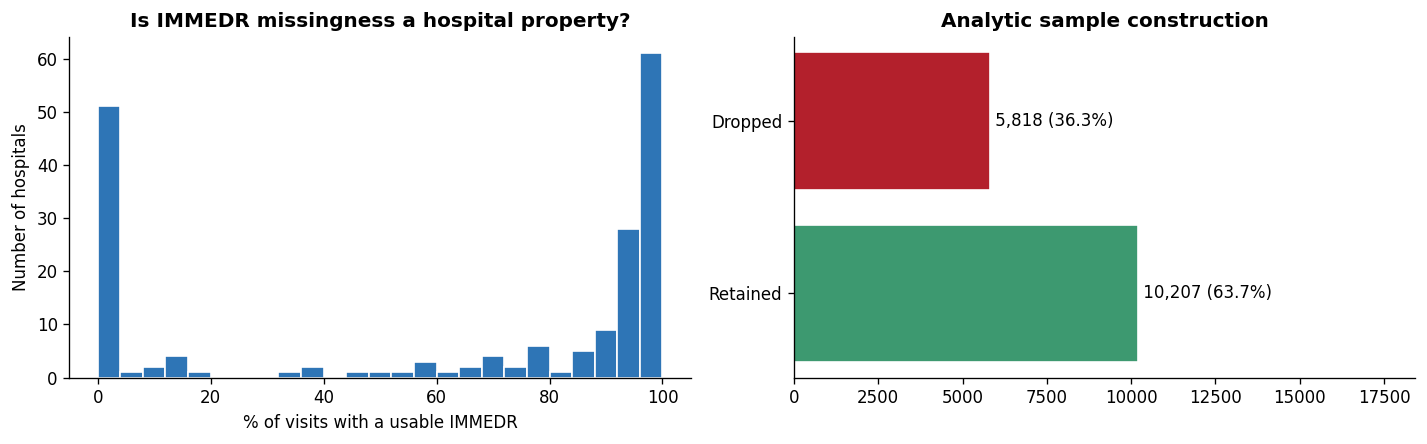


VERIFY: a bimodal histogram (mass at 0% and at 100%) means exclusion is
driven by ED recording policy, not by patient characteristics. That is a
*selection of hospitals*, and it caps the external validity of everything after.


In [ ]:
# IMMEDR exclusion accounting: who are the ~36% of visits with no IMMEDR?

immedr_raw = pd.to_numeric(df_raw['IMMEDR'], errors='coerce')
print("RAW IMMEDR value counts (before any filtering)")
print(immedr_raw.value_counts(dropna=False).sort_index().to_string())

keep_mask = immedr_raw.isin(IMMEDR_LEVELS)
n_keep, n_drop = int(keep_mask.sum()), int((~keep_mask).sum())
print(f"\nRetained : {n_keep:,} ({n_keep/len(df_raw)*100:.1f}%)")
print(f"Dropped  : {n_drop:,} ({n_drop/len(df_raw)*100:.1f}%)")

# standardized mean differences: dropped vs retained
def smd(a, b):
    """Standardized mean difference; |SMD| > 0.10 is the usual imbalance threshold."""
    a, b = pd.Series(a).dropna(), pd.Series(b).dropna()
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    return (a.mean() - b.mean()) / pooled if pooled > 0 else np.nan

compare_cols = [c for c in ['AGE', 'SEX', 'RACERETH', 'WAITTIME', 'LOV', 'PAINSCALE',
                            'ARREMS', 'SEEN72', 'INJURY'] + VITALS if c in df.columns]
smd_rows = []
for c in compare_cols:
    smd_rows.append({
        'column': c,
        'retained_mean': round(df.loc[keep_mask, c].mean(), 2),
        'dropped_mean' : round(df.loc[~keep_mask, c].mean(), 2),
        'SMD'          : round(smd(df.loc[~keep_mask, c], df.loc[keep_mask, c]), 3),
        'retained_pct_missing': round(df.loc[keep_mask, c].isna().mean()*100, 1),
        'dropped_pct_missing' : round(df.loc[~keep_mask, c].isna().mean()*100, 1)})

smd_df = pd.DataFrame(smd_rows).sort_values('SMD', key=abs, ascending=False)
print("\nDROPPED vs RETAINED - standardized mean differences")
print(smd_df.to_string(index=False))
# does the missingness cluster by hospital?
if HOSPID:
    by_hosp = (pd.DataFrame({'h': df_raw[HOSPID], 'keep': keep_mask})
               .groupby('h')['keep'].agg(['mean', 'size'])
               .rename(columns={'mean': 'pct_with_IMMEDR', 'size': 'n_visits'}))
    by_hosp = by_hosp[by_hosp['n_visits'] >= 10]
    n_never = int((by_hosp['pct_with_IMMEDR'] == 0).sum())
    n_always = int((by_hosp['pct_with_IMMEDR'] > 0.95).sum())
    print(f"\nHOSPITAL-LEVEL CLUSTERING of IMMEDR recording ({len(by_hosp)} units, n>=10)")
    print(f"  never record IMMEDR (0%)       : {n_never}  <- these EDs vanish entirely")
    print(f"  essentially always (>95%)      : {n_always}")
    print(f"  median coverage across units   : {by_hosp['pct_with_IMMEDR'].median():.1%}")
    print(by_hosp['pct_with_IMMEDR'].describe().round(3).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    axes[0].hist(by_hosp['pct_with_IMMEDR']*100, bins=25, color='#2E75B6',
                 edgecolor='white')
    axes[0].set_xlabel('% of visits with a usable IMMEDR')
    axes[0].set_ylabel('Number of hospitals')
    axes[0].set_title('Is IMMEDR missingness a hospital property?')
    axes[1].barh(['Retained', 'Dropped'], [n_keep, n_drop],
                 color=['#3D9970', '#B3202C'], edgecolor='white')
    for i, v in enumerate([n_keep, n_drop]):
        axes[1].text(v, i, f' {v:,} ({v/len(df_raw)*100:.1f}%)', va='center')
    axes[1].set_title('Analytic sample construction')
    axes[1].set_xlim(0, len(df_raw)*1.15)
    plt.tight_layout(); plt.savefig('fig_01_immedr_exclusion.png', bbox_inches='tight')
    plt.show()

In [ ]:
# apply the analytic filter and physiologic plausibility bounds

df = df.loc[keep_mask].copy()
df['IMMEDR'] = df['IMMEDR'].astype(int)

bound_report = []
for col, (lo, hi) in VITAL_BOUNDS.items():
    if col not in df.columns:
        continue
    s = pd.to_numeric(df[col], errors='coerce')
    bad = ((s < lo) | (s > hi)) & s.notna()
    if bad.any():
        bound_report.append({'column': col, 'bounds': f'[{lo}, {hi}]',
                             'n_out_of_range': int(bad.sum()),
                             'pct': round(bad.mean()*100, 2)})
    df[col] = s.mask(bad)

br = pd.DataFrame(bound_report)
print("PLAUSIBILITY BOUNDS - values set to NaN")
print(br.to_string(index=False) if len(br) else "  (nothing out of range)")

print(f"ANALYTIC SAMPLE: {len(df):,} visits")
print("\nIMMEDR distribution")
dist = df['IMMEDR'].value_counts().reindex(IMMEDR_LEVELS)
dist_tbl = pd.DataFrame({'n': dist, 'pct': (dist/len(df)*100).round(1),
                         'label': [IMMEDR_LABELS[l] for l in IMMEDR_LEVELS]})
print(dist_tbl.to_string())

PLAUSIBILITY BOUNDS - values set to NaN
column    bounds  n_out_of_range  pct
 PULSE [20, 300]               9 0.09
 RESPR   [4, 80]              19 0.19
 TEMPF [80, 112]             299 2.93
 POPCT [50, 100]              32 0.31
   LOV [0, 4320]              16 0.16

VERIFY: these bounds are deliberately wide. They remove impossibilities
(a temperature of 12F), not clinical outliers. A high pct here means the
sentinel sweep above missed a code - go back and check.

ANALYTIC SAMPLE: 10,207 visits

IMMEDR distribution
           n   pct          label
IMMEDR                           
1        139   1.4    1 Immediate
2       1595  15.6     2 Emergent
3       5340  52.3       3 Urgent
4       2826  27.7  4 Semi-urgent
5        307   3.0   5 Non-urgent

VERIFY: levels 1 (n=139) and 5 (n=307) are small. Every per-level
estimate at the extremes needs a confidence interval, and any subgroup cell
below MIN_CELL_N=30 will be suppressed rather than reported.


In [ ]:
# derive arrival hour, demographic labels, and outcome flags

df['HOUR'] = (pd.to_numeric(df['ARRTIME'], errors='coerce') // 100).clip(0, 23)
df['TIME_OF_DAY'] = pd.cut(df['HOUR'], bins=TIME_OF_DAY_BINS, labels=TIME_OF_DAY_LABELS)

if 'SEX' in df.columns:      df['SEX_LBL']  = df['SEX'].map(SEX_MAP)
if 'RACERETH' in df.columns: df['RACE_LBL'] = df['RACERETH'].map(RACERETH_MAP)
if 'PAYTYPER' in df.columns: df['PAY_LBL']  = df['PAYTYPER'].map(PAYTYPER_MAP)
df['AGE_GRP'] = pd.cut(df['AGE'], bins=AGE_BINS, labels=AGE_LABELS, right=False)

# Left-without-being-seen / left-early flags: the censoring mechanism for wait time.
have_lwbs = [c for c in LWBS_COLS if c in df.columns]
if have_lwbs:
    df['LEFT_EARLY'] = (df[have_lwbs].fillna(0) == 1).any(axis=1).astype(int)
    print("LEFT-EARLY FLAGS (the censoring mechanism for WAITTIME)")
    for c in have_lwbs:
        print(f"  {c:<10} n = {int((df[c] == 1).sum()):,}")
    print(f"  ANY        n = {int(df['LEFT_EARLY'].sum()):,} "
          f"({df['LEFT_EARLY'].mean()*100:.1f}% of the analytic sample)")
    print("\n  by IMMEDR level:")
    lw = df.groupby('IMMEDR')['LEFT_EARLY'].agg(['sum', 'mean', 'size'])
    lw.columns = ['n_left', 'rate', 'n_total']
    lw['rate'] = (lw['rate']*100).round(2)
    print(lw.to_string())

else:
    df['LEFT_EARLY'] = 0
    print("No LWBS columns found - censoring analysis in Section 6 will be skipped.")

print("\nDecoded value checks (confirm the config maps match the codebook):")
for c in ['SEX_LBL', 'RACE_LBL', 'PAY_LBL', 'AGE_GRP']:
    if c in df.columns:
        vc = df[c].value_counts(dropna=False)
        print(f"\n{c}:\n{vc.to_string()}")

LEFT-EARLY FLAGS (the censoring mechanism for WAITTIME)
  LEFTAMA    n = 160
  ANY        n = 160 (1.6% of the analytic sample)

  by IMMEDR level:
        n_left  rate  n_total
IMMEDR                       
1            0  0.00      139
2           30  1.88     1595
3           82  1.54     5340
4           40  1.42     2826
5            8  2.61      307

  VERIFY: if the rate rises at levels 4-5, the observed mean wait at those
  levels is survivorship-biased DOWNWARD and the inverted-U may be an
  artifact. Section 6 tests this with censored (Kaplan-Meier) estimates.

Decoded value checks (confirm the config maps match the codebook):

SEX_LBL:
SEX_LBL
Female    5356
Male      4851

RACE_LBL:
RACE_LBL
NH White    5599
NH Black    2438
Hispanic    1741
NH Asian     429

PAY_LBL:
PAY_LBL
Medicaid       3950
Private        2519
Medicare       2154
NaN             763
Self-pay        519
Other           203
Worker comp      67
No charge        32

AGE_GRP:
AGE_GRP
25-44    2696
45-64    

## Section 2: Exploratory Data Analysis

The goal of this section is a per-level portrait: what does a patient at each IMMEDR level look like, and what does the system do to them

In [ ]:
# column-level profiling table for every analysis variable

def profile(frame, cols):
    rows = []
    for c in cols:
        if c not in frame.columns:
            continue
        s = frame[c]
        r = {'column': c, 'dtype': str(s.dtype), 'n_valid': int(s.notna().sum()),
             'pct_missing': round(s.isna().mean()*100, 1), 'n_unique': int(s.nunique())}
        if pd.api.types.is_numeric_dtype(s) and s.notna().any():
            q = s.quantile([.01, .25, .5, .75, .99])
            r.update({'mean': round(s.mean(), 2), 'sd': round(s.std(), 2),
                      'p1': round(q[.01], 1), 'p25': round(q[.25], 1),
                      'median': round(q[.50], 1), 'p75': round(q[.75], 1),
                      'p99': round(q[.99], 1),
                      'skew': round(s.skew(), 2)})
        rows.append(r)
    return pd.DataFrame(rows)

prof_cols = (['IMMEDR', 'WAITTIME', 'LOV', 'AGE', 'PAINSCALE', 'HOUR'] + VITALS +
             [c for c in ['SEEN72', 'INJURY', 'ARREMS', 'LEFT_EARLY',
                          SURVEY_WEIGHT_COL] if c in df.columns])
prof = profile(df, prof_cols)
pd.set_option('display.width', 200, 'display.max_columns', 50)
print("COLUMN PROFILE - analytic sample")
print(prof.to_string(index=False))

COLUMN PROFILE - analytic sample
    column   dtype  n_valid  pct_missing  n_unique        mean      sd    p1    p25  median     p75     p99  skew
    IMMEDR   int64    10207          0.0         5    3.150000    0.76   1.0    3.0     3.0     4.0     5.0 -0.05
  WAITTIME float64     8638         15.4       340   35.190000   61.58   0.0    5.0    15.0    38.0   291.6  4.90
       LOV float64     9962          2.4      1209  296.060000  350.00  22.0  117.0   204.0   338.0  1797.8  4.54
       AGE   int16    10207          0.0        95   41.070000   24.73   0.0   21.0    40.0    61.0    91.0  0.11
 PAINSCALE float64     7223         29.2        11    4.490000    3.73   0.0    0.0     5.0     8.0    10.0  0.00
      HOUR   int64    10207          0.0        24   13.140000    6.02   0.0    9.0    13.0    18.0    23.0 -0.38
     PULSE float64     9992          2.1       165   92.140000   22.73  53.0   77.0    89.0   103.0   166.1  1.11
     RESPR float64     9949          2.5        56   19

IMMEDR DISTRIBUTION - sample vs national
               n_sample  unweighted_pct  weighted_pct  abs_diff  national_est_visits
1 Immediate         139            1.36      1.500000      0.14            1521344.0
2 Emergent         1595           15.63     15.420000     -0.21           15653820.0
3 Urgent           5340           52.32     50.740002     -1.58           51507824.0
4 Semi-urgent      2826           27.69     29.639999      1.96           30093902.0
5 Non-urgent        307            3.01      2.710000     -0.30            2746218.0

Total national ED visits represented: 101,523,112

VERIFY: abs_diff > ~2 points on any level means the unweighted sample
materially misrepresents the national case mix, and every headline number
must be reported weighted. Small diffs mean you may report unweighted with a note.


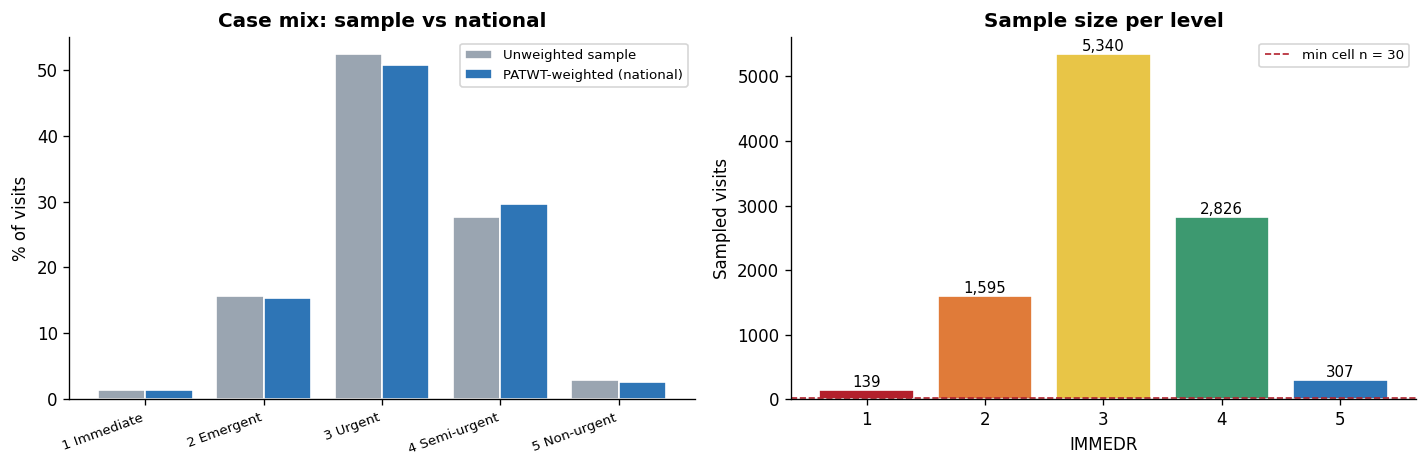

In [ ]:
# IMMEDR distribution, unweighted vs survey-weighted

unw = df['IMMEDR'].value_counts(normalize=True).reindex(IMMEDR_LEVELS) * 100
if SURVEY_WEIGHT_COL in df.columns:
    w = df.groupby('IMMEDR')[SURVEY_WEIGHT_COL].sum().reindex(IMMEDR_LEVELS)
    wtd = w / w.sum() * 100
    natl = w   # national annual visit estimate per level
else:
    wtd, natl = unw.copy(), pd.Series(np.nan, index=IMMEDR_LEVELS)

comp = pd.DataFrame({'n_sample': df['IMMEDR'].value_counts().reindex(IMMEDR_LEVELS),
                     'unweighted_pct': unw.round(2),
                     'weighted_pct': wtd.round(2),
                     'abs_diff': (wtd - unw).round(2),
                     'national_est_visits': natl.round(0)})
comp.index = [IMMEDR_LABELS[l] for l in IMMEDR_LEVELS]
print("IMMEDR DISTRIBUTION - sample vs national")
print(comp.to_string())
print(f"\nTotal national ED visits represented: {natl.sum():,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(5)
axes[0].bar(x-0.2, unw.values, width=0.4, label='Unweighted sample',
            color='#9AA5B1', edgecolor='white')
axes[0].bar(x+0.2, wtd.values, width=0.4, label='PATWT-weighted (national)',
            color='#2E75B6', edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels([IMMEDR_LABELS[l] for l in IMMEDR_LEVELS],
                                               rotation=20, ha='right', fontsize=8)
axes[0].set_ylabel('% of visits'); axes[0].legend(fontsize=8)
axes[0].set_title('Case mix: sample vs national')
bars = axes[1].bar(x, df['IMMEDR'].value_counts().reindex(IMMEDR_LEVELS).values,
                   color=IMMEDR_COLORS, edgecolor='white')
for b, v in zip(bars, df['IMMEDR'].value_counts().reindex(IMMEDR_LEVELS).values):
    axes[1].text(b.get_x()+b.get_width()/2, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
axes[1].axhline(MIN_CELL_N, color='#B3202C', ls='--', lw=1,
                label=f'min cell n = {MIN_CELL_N}')
axes[1].set_xticks(x); axes[1].set_xticklabels(IMMEDR_LEVELS)
axes[1].set_xlabel('IMMEDR'); axes[1].set_ylabel('Sampled visits')
axes[1].set_title('Sample size per level'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig('fig_02_immedr_distribution.png', bbox_inches='tight')
plt.show()

WAIT TIME BY ACUITY LEVEL (minutes)
                  n  mean  median   p75   p90    p95    sd  CTAS_target  gap_mean  gap_median
1 Immediate     112  24.9     9.5  23.2  54.5   68.8  50.1            0      24.9         9.5
2 Emergent     1354  28.5    12.0  29.0  65.0  105.7  59.0           15      13.5        -3.0
3 Urgent       4525  37.6    15.0  40.0  96.6  154.0  66.0           30       7.6       -15.0
4 Semi-urgent  2384  35.5    15.0  41.0  91.0  137.0  55.5           60     -24.5       -45.0
5 Non-urgent    263  30.8    13.0  32.0  78.2  112.9  49.7          120     -89.2      -107.0

VERIFY - this table is the spine of the paper. Read it for:
  * non-monotonicity: does mean/median peak at level 3 rather than level 5?
  * the sign flip: gap positive for 1-3, negative for 4-5?
  * the tails: p90 for level 1 is the number that matters clinically, not the mean.

Kruskal-Wallis across the 5 levels: H = 64.3, p = 3.56e-13

PAIRWISE WAIT-TIME COMPARISONS (Mann-Whitney, BH-FDR)
  pai

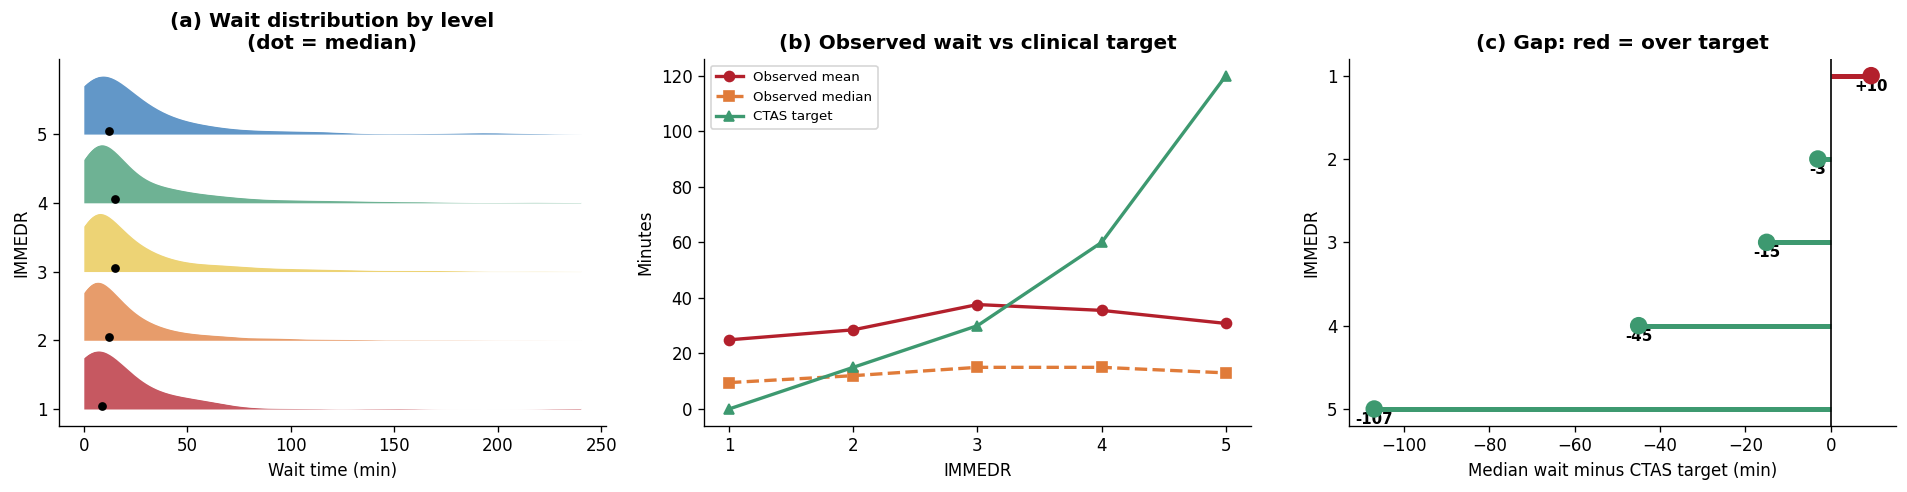

In [ ]:
# wait time by IMMEDR

wt = df.dropna(subset=['WAITTIME'])
summ = wt.groupby('IMMEDR')['WAITTIME'].agg(
    n='size', mean='mean', median='median',
    p75=lambda s: s.quantile(.75), p90=lambda s: s.quantile(.90),
    p95=lambda s: s.quantile(.95), sd='std').reindex(IMMEDR_LEVELS).round(1)
summ['CTAS_target'] = [TARGET_MINUTES[l] for l in IMMEDR_LEVELS]
summ['gap_mean']    = (summ['mean']   - summ['CTAS_target']).round(1)
summ['gap_median']  = (summ['median'] - summ['CTAS_target']).round(1)
summ.index = [IMMEDR_LABELS[l] for l in IMMEDR_LEVELS]
print("WAIT TIME BY ACUITY LEVEL (minutes)")
print(summ.to_string())

# Kruskal-Wallis across levels, then pairwise Mann-Whitney with BH-FDR at alpha=0.01
groups = [wt.loc[wt['IMMEDR'] == l, 'WAITTIME'].values for l in IMMEDR_LEVELS]
H, p_kw = stats.kruskal(*groups)
print(f"\nKruskal-Wallis across the 5 levels: H = {H:.1f}, p = {p_kw:.3g}")

def cliffs_delta(a, b):
    """Nonparametric effect size in [-1, 1]. |d|: .11 small, .28 medium, .43 large."""
    a, b = np.asarray(a), np.asarray(b)
    if len(a) == 0 or len(b) == 0:
        return np.nan
    n = min(len(a), 20000); m = min(len(b), 20000)
    a = np.random.choice(a, n, replace=False) if len(a) > n else a
    b = np.random.choice(b, m, replace=False) if len(b) > m else b
    gt = sum((a[:, None] > b[None, :]).sum(axis=1))
    lt = sum((a[:, None] < b[None, :]).sum(axis=1))
    return (gt - lt) / (len(a)*len(b))

def bh_fdr(pvals, alpha):
    """Benjamini-Hochberg; returns (rejected, adjusted p)."""
    p = np.asarray(pvals); k = len(p); order = np.argsort(p)
    adj = np.empty(k); run = 1.0
    for i in range(k-1, -1, -1):
        run = min(run, p[order[i]] * k / (i+1)); adj[order[i]] = run
    return adj <= alpha, adj

rows = []
for a, b in itertools.combinations(IMMEDR_LEVELS, 2):
    x1 = wt.loc[wt['IMMEDR'] == a, 'WAITTIME']; x2 = wt.loc[wt['IMMEDR'] == b, 'WAITTIME']
    if len(x1) < MIN_CELL_N or len(x2) < MIN_CELL_N:
        continue
    u, p = stats.mannwhitneyu(x1, x2, alternative='two-sided')
    rows.append({'pair': f'{a} vs {b}', 'n1': len(x1), 'n2': len(x2),
                 'median1': round(x1.median(), 1), 'median2': round(x2.median(), 1),
                 'diff': round(x1.median()-x2.median(), 1),
                 'cliffs_delta': round(cliffs_delta(x1.values, x2.values), 3), 'p_raw': p})
pw = pd.DataFrame(rows)
rej, adj = bh_fdr(pw['p_raw'].values, FDR_ALPHA)
pw['p_BH'] = adj.round(5); pw['sig_at_%.2f' % FDR_ALPHA] = rej
pw['p_raw'] = pw['p_raw'].round(5)
print("\nPAIRWISE WAIT-TIME COMPARISONS (Mann-Whitney, BH-FDR)")
print(pw.to_string(index=False))

#  the figure
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
# (a) ridgeline
for i, l in enumerate(IMMEDR_LEVELS):
    d = wt.loc[wt['IMMEDR'] == l, 'WAITTIME']
    d = d[d <= d.quantile(.99)]
    if len(d) < 10: continue
    kde = stats.gaussian_kde(d)
    grid = np.linspace(0, 240, 300)
    y = kde(grid); y = y / y.max() * 0.85
    axes[0].fill_between(grid, i, i + y, color=IMMEDR_CMAP[l], alpha=.75, lw=0)
    axes[0].plot(grid, i + y, color='white', lw=1)
    axes[0].scatter([d.median()], [i + 0.05], color='black', s=18, zorder=5)
axes[0].set_yticks(range(5)); axes[0].set_yticklabels(IMMEDR_LEVELS)
axes[0].set_xlabel('Wait time (min)'); axes[0].set_ylabel('IMMEDR')
axes[0].set_title('(a) Wait distribution by level\n(dot = median)')
# (b) the inverted U with the target line
axes[1].plot(IMMEDR_LEVELS, summ['mean'].values, 'o-', color='#B3202C', lw=2,
             label='Observed mean')
axes[1].plot(IMMEDR_LEVELS, summ['median'].values, 's--', color='#E07B39', lw=2,
             label='Observed median')
axes[1].plot(IMMEDR_LEVELS, [TARGET_MINUTES[l] for l in IMMEDR_LEVELS], '^-',
             color='#3D9970', lw=2, label='CTAS target')
axes[1].set_xticks(IMMEDR_LEVELS); axes[1].set_xlabel('IMMEDR')
axes[1].set_ylabel('Minutes'); axes[1].legend(fontsize=8)
axes[1].set_title('(b) Observed wait vs clinical target')
# (c) gap lollipop
gaps = summ['gap_median'].values
cols = ['#B3202C' if g > 0 else '#3D9970' for g in gaps]
axes[2].hlines(IMMEDR_LEVELS, 0, gaps, color=cols, lw=3)
axes[2].scatter(gaps, IMMEDR_LEVELS, color=cols, s=90, zorder=5)
for l, g in zip(IMMEDR_LEVELS, gaps):
    axes[2].text(g, l+0.18, f'{g:+.0f}', ha='center', fontsize=9, fontweight='bold')
axes[2].axvline(0, color='black', lw=1)
axes[2].invert_yaxis(); axes[2].set_yticks(IMMEDR_LEVELS)
axes[2].set_xlabel('Median wait minus CTAS target (min)')
axes[2].set_ylabel('IMMEDR')
axes[2].set_title('(c) Gap: red = over target')
plt.tight_layout(); plt.savefig('fig_03_wait_by_acuity.png', bbox_inches='tight')
plt.show()

VITALS FINGERPRINT - mean z-score by acuity level
(0 = the overall ED average; +1 = one SD above it)
        PULSE  RESPR  TEMPF  BPSYS  BPDIAS  POPCT  PAINSCALE    AGE
IMMEDR                                                             
1       0.005  0.171 -0.239 -0.175   0.008 -0.654     -0.295  0.447
2       0.082  0.139  0.006  0.133   0.091 -0.214     -0.143  0.324
3      -0.060 -0.054 -0.003  0.045   0.009  0.002      0.074  0.114
4       0.071  0.011  0.028 -0.151  -0.065  0.136     -0.018 -0.389
5      -0.043  0.050 -0.149 -0.129  -0.093  0.099     -0.382 -0.295

Standard errors
        PULSE  RESPR  TEMPF  BPSYS  BPDIAS  POPCT  PAINSCALE    AGE
IMMEDR                                                             
1       0.101  0.128  0.124  0.110   0.123  0.233      0.133  0.087
2       0.027  0.032  0.027  0.031   0.031  0.033      0.032  0.024
3       0.013  0.013  0.013  0.014   0.014  0.013      0.016  0.013
4       0.019  0.018  0.020  0.018   0.018  0.015      0.022  0.01

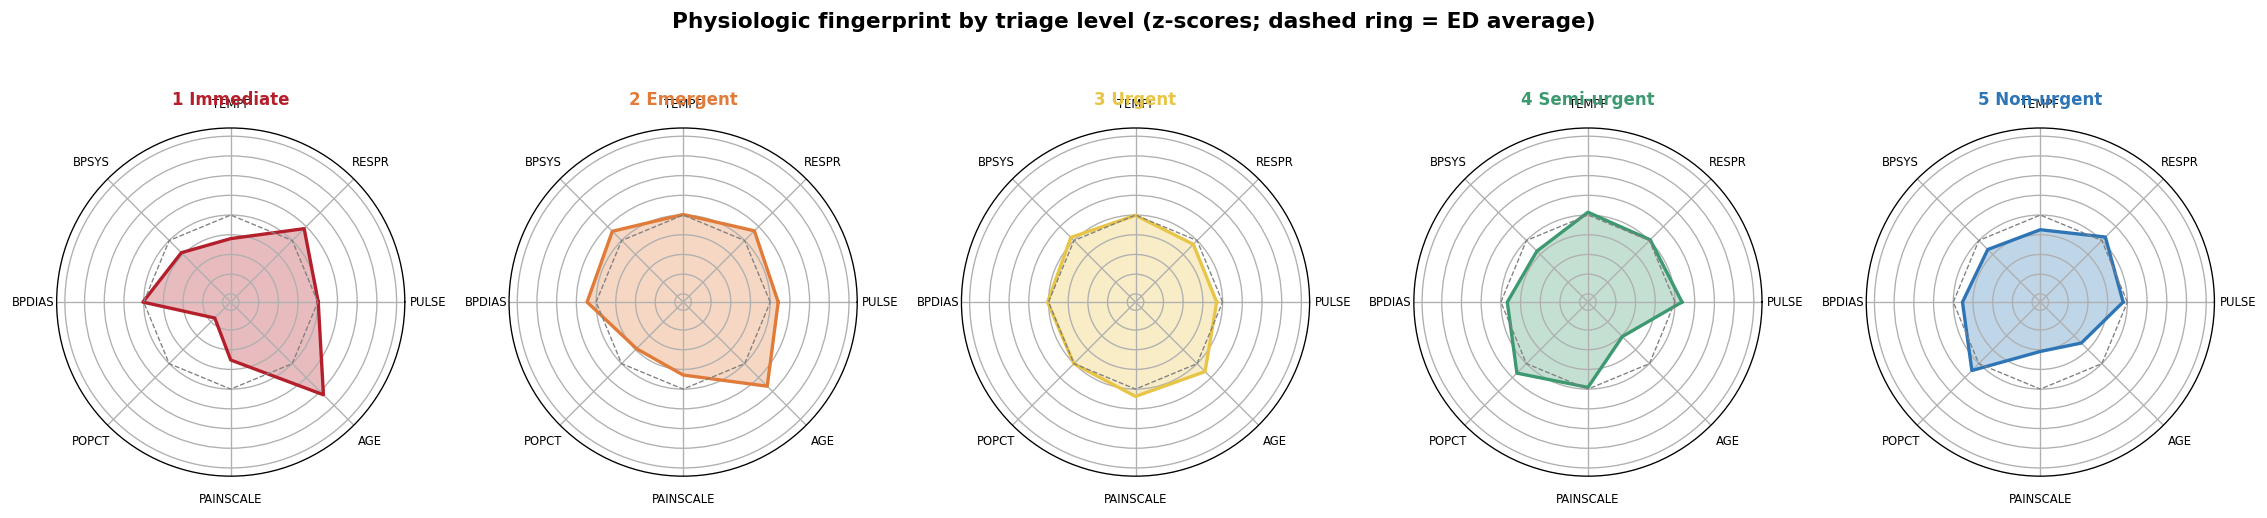

In [ ]:
# vitals fingerprint per IMMEDR level - z-scored radar panel

fp_vitals = [c for c in VITALS + ['PAINSCALE', 'AGE'] if c in df.columns
             and df[c].notna().sum() > MIN_CELL_N*5]
z = df[fp_vitals].apply(lambda s: (s - s.mean()) / s.std())
z['IMMEDR'] = df['IMMEDR']
centroids = z.groupby('IMMEDR')[fp_vitals].mean().reindex(IMMEDR_LEVELS)
sems = z.groupby('IMMEDR')[fp_vitals].sem().reindex(IMMEDR_LEVELS)

print("VITALS FINGERPRINT - mean z-score by acuity level")
print("(0 = the overall ED average; +1 = one SD above it)")
print(centroids.round(3).to_string())
print("\nStandard errors")
print(sems.round(3).to_string())

ang = np.linspace(0, 2*np.pi, len(fp_vitals), endpoint=False).tolist()
ang += ang[:1]
fig, axes = plt.subplots(1, 5, figsize=(19, 4), subplot_kw=dict(polar=True))
lim = float(np.nanmax(np.abs(centroids.values))) * 1.35
for ax, l in zip(axes, IMMEDR_LEVELS):
    vals = centroids.loc[l].tolist(); vals += vals[:1]
    ax.plot(ang, vals, color=IMMEDR_CMAP[l], lw=2)
    ax.fill(ang, vals, color=IMMEDR_CMAP[l], alpha=.3)
    ax.plot(ang, [0]*len(ang), color='grey', lw=.8, ls='--')
    ax.set_xticks(ang[:-1]); ax.set_xticklabels(fp_vitals, fontsize=7)
    ax.set_ylim(-lim, lim); ax.set_yticklabels([])
    ax.set_title(IMMEDR_LABELS[l], color=IMMEDR_CMAP[l], fontsize=10, pad=14)
fig.suptitle('Physiologic fingerprint by triage level (z-scores; dashed ring = ED average)',
             fontsize=13, fontweight='bold', y=1.06)
plt.tight_layout(); plt.savefig('fig_04_vitals_fingerprint.png', bbox_inches='tight')
plt.show()

JONCKHEERE-TERPSTRA TREND TESTS across IMMEDR 1->5
(remember: level 1 = sickest, so 'rises with level number' = higher in WELL patients)
   column note     z    p_raw               direction  spearman_rho     p_BH monotone
    PULSE      -0.53    0.593 rises with level number         0.005    0.742    False
    RESPR       1.61    0.106 falls with level number        -0.016    0.152    False
    TEMPF       0.40    0.692 falls with level number        -0.004    0.769    False
    BPSYS       8.26 2.22e-16 falls with level number        -0.084 5.55e-16     True
   BPDIAS       3.99 6.63e-05 falls with level number        -0.041  0.00011     True
    POPCT      -9.35        0 rises with level number         0.095        0     True
PAINSCALE       0.29    0.769 falls with level number        -0.002    0.769    False
      AGE      26.07        0 falls with level number        -0.257        0     True
 WAITTIME      -5.97 2.34e-09 rises with level number         0.065 4.68e-09     True
   

/tmp/ipykernel_3175/2503052221.py:53: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cols = ['#B3202C' if m else '#9AA5B1' for m in plot_tr['monotone'].fillna(False)]


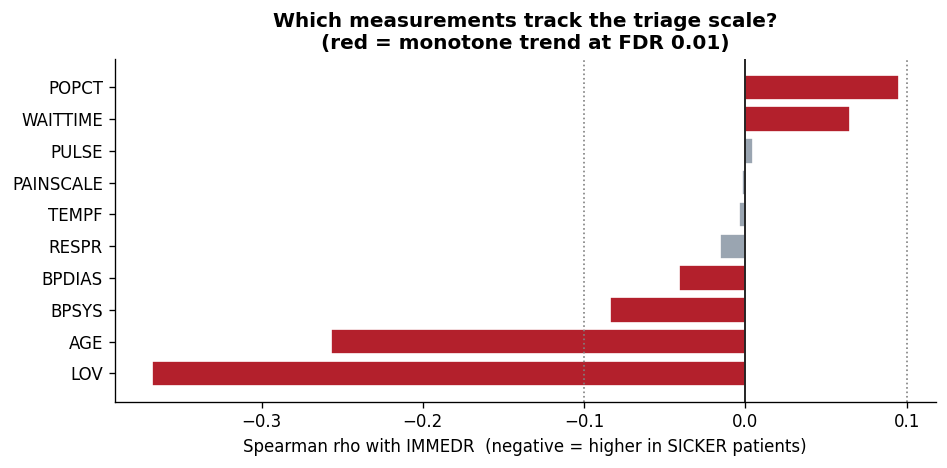

In [ ]:
# monotonic trend tests across ordered levels (Jonckheere-Terpstra)

def jonckheere(groups):
    """JT test for monotone trend across ORDERED groups. Normal approximation.
    Returns (J, z, two-sided p). Sensitive to ordered alternatives in a way that
    Kruskal-Wallis is not - the right test when the grouping variable is a scale."""
    groups = [np.asarray(g)[~np.isnan(np.asarray(g, dtype=float))] for g in groups]
    k = len(groups); ns = np.array([len(g) for g in groups]); N = ns.sum()
    J = 0
    for i in range(k-1):
        for j in range(i+1, k):
            a, b = groups[i], groups[j]
            if len(a) == 0 or len(b) == 0: continue
            # U statistic via rank trick (avoids an n*m matrix on large groups)
            comb = np.concatenate([a, b]); r = stats.rankdata(comb)
            J += r[:len(a)].sum() - len(a)*(len(a)+1)/2
    mu = (N**2 - (ns**2).sum()) / 4
    sd = np.sqrt((N**2*(2*N+3) - (ns**2*(2*ns+3)).sum()) / 72)
    zst = (J - mu) / sd if sd > 0 else np.nan
    return J, zst, 2*(1 - stats.norm.cdf(abs(zst)))

trend_cols = [c for c in VITALS + ['PAINSCALE', 'AGE', 'WAITTIME', 'LOV']
              if c in df.columns]
rows = []
for c in trend_cols:
    gs = [df.loc[df['IMMEDR'] == l, c].dropna().values for l in IMMEDR_LEVELS]
    if min(len(g) for g in gs) < MIN_CELL_N:
        rows.append({'column': c, 'note': 'a level has n < MIN_CELL_N', 'z': np.nan,
                     'p_raw': np.nan, 'direction': '-', 'spearman_rho': np.nan})
        continue
    J, zst, p = jonckheere(gs)
    sub = df[['IMMEDR', c]].dropna()
    rho, _ = stats.spearmanr(sub['IMMEDR'], sub[c])
    rows.append({'column': c, 'note': '', 'z': round(zst, 2), 'p_raw': p,
                 'direction': 'rises with level number' if rho > 0 else 'falls with level number',
                 'spearman_rho': round(rho, 3)})
tr = pd.DataFrame(rows)
ok = tr['p_raw'].notna()
rej, adj = bh_fdr(tr.loc[ok, 'p_raw'].values, FDR_ALPHA)
tr.loc[ok, 'p_BH'] = adj; tr.loc[ok, 'monotone'] = rej
tr['p_raw'] = tr['p_raw'].apply(lambda v: f'{v:.3g}' if pd.notna(v) else '')
tr['p_BH']  = tr['p_BH'].apply(lambda v: f'{v:.3g}' if pd.notna(v) else '')
print("JONCKHEERE-TERPSTRA TREND TESTS across IMMEDR 1->5")
print("(remember: level 1 = sickest, so 'rises with level number' = higher in WELL patients)")
print(tr.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
plot_tr = tr.dropna(subset=['spearman_rho']).sort_values('spearman_rho')
cols = ['#B3202C' if m else '#9AA5B1' for m in plot_tr['monotone'].fillna(False)]
ax.barh(plot_tr['column'], plot_tr['spearman_rho'], color=cols, edgecolor='white')
ax.axvline(0, color='black', lw=1)
for t in (-0.1, 0.1):
    ax.axvline(t, color='grey', ls=':', lw=1)
ax.set_xlabel("Spearman rho with IMMEDR  (negative = higher in SICKER patients)")
ax.set_title('Which measurements track the triage scale?\n(red = monotone trend at FDR %.2f)' % FDR_ALPHA)
plt.tight_layout(); plt.savefig('fig_05_trend_tests.png', bbox_inches='tight'); plt.show()

ARRIVALS BY HOUR (counts)
IMMEDR   1    2    3    4   5
HOUR                         
0       10   44  171   92  16
1        4   36  104   65   8
2        1   29   96   49   3
3        1   34   89   46   7
4        4   22   93   46   6
5        5   22   72   52   4
6        6   39  132   52   0
7        4   41  139   69   5
8        4   64  200  126  13
9        7   65  284  139  19
10       9   82  356  174  31
11       9  104  335  160  17
12       3  101  327  175  17
13      11   95  321  164  27
14       9   94  295  126  14
15       5   94  284  131  17
16       3   96  296  147  13
17      10   97  310  185  19
18       6  102  281  158  12
19       6   85  266  186  10
20       4   70  269  138  15
21       5   73  224  138  12
22       8   62  210  128   9
23       5   44  186   80  13

MEDIAN WAIT BY HOUR x LEVEL
IMMEDR     1     2     3     4     5
HOUR                                
0       12.0   6.0  13.0  16.0   4.0
1       13.0  13.0  11.0  10.0  10.0
2       34.0  10.

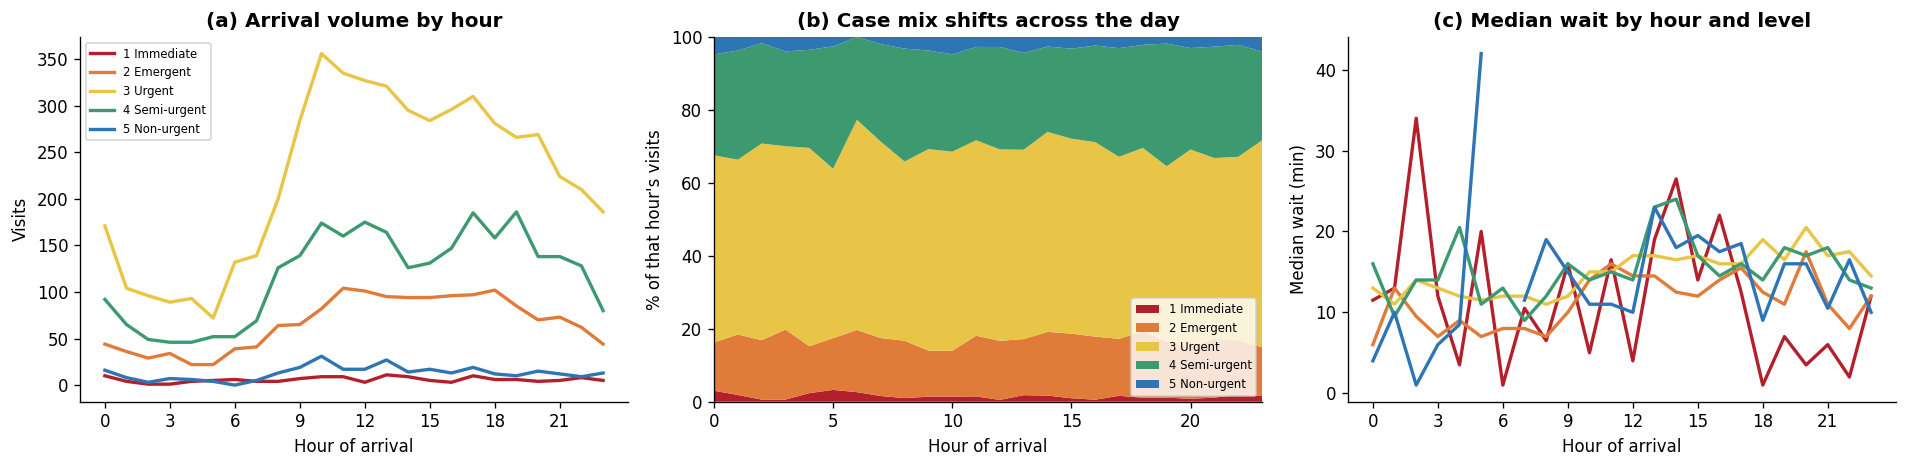

In [ ]:
# circadian and weekday structure within each IMMEDR level

hourly = df.groupby(['HOUR', 'IMMEDR']).size().unstack('IMMEDR').reindex(columns=IMMEDR_LEVELS).fillna(0)
hourly_share = hourly.div(hourly.sum(axis=1), axis=0) * 100
wait_by_hour = df.dropna(subset=['WAITTIME']).groupby(['HOUR', 'IMMEDR'])['WAITTIME'] \
                 .median().unstack('IMMEDR').reindex(columns=IMMEDR_LEVELS)

print("ARRIVALS BY HOUR (counts)")
print(hourly.astype(int).to_string())
print("\nMEDIAN WAIT BY HOUR x LEVEL")
print(wait_by_hour.round(0).to_string())
peak = hourly.sum(axis=1).idxmax(); trough = hourly.sum(axis=1).idxmin()
print(f"\nBusiest arrival hour: {peak}:00   Quietest: {trough}:00")
print("Median wait at those hours, by level:")
print(wait_by_hour.loc[[trough, peak]].round(0).to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for l in IMMEDR_LEVELS:
    axes[0].plot(hourly.index, hourly[l], color=IMMEDR_CMAP[l], lw=2, label=IMMEDR_LABELS[l])
axes[0].set_xlabel('Hour of arrival'); axes[0].set_ylabel('Visits')
axes[0].set_xticks(range(0, 24, 3)); axes[0].legend(fontsize=7)
axes[0].set_title('(a) Arrival volume by hour')
axes[1].stackplot(hourly_share.index, [hourly_share[l] for l in IMMEDR_LEVELS],
                  colors=IMMEDR_COLORS, labels=[IMMEDR_LABELS[l] for l in IMMEDR_LEVELS])
axes[1].set_xlabel('Hour of arrival'); axes[1].set_ylabel('% of that hour\'s visits')
axes[1].set_xlim(0, 23); axes[1].set_ylim(0, 100); axes[1].legend(fontsize=7, loc='lower right')
axes[1].set_title('(b) Case mix shifts across the day')
for l in IMMEDR_LEVELS:
    axes[2].plot(wait_by_hour.index, wait_by_hour[l], color=IMMEDR_CMAP[l], lw=2)
axes[2].set_xlabel('Hour of arrival'); axes[2].set_ylabel('Median wait (min)')
axes[2].set_xticks(range(0, 24, 3))
axes[2].set_title('(c) Median wait by hour and level')
plt.tight_layout(); plt.savefig('fig_06_circadian.png', bbox_inches='tight'); plt.show()

MISSINGNESS BY ACUITY LEVEL - is the absence of a measurement informative?
   column  L1_pct_missing  L2_pct_missing  L3_pct_missing  L4_pct_missing  L5_pct_missing  spread  chi2    p_raw     p_BH  sig
    PULSE            12.9             2.1             1.9             1.8             3.6    11.1  84.8 1.71e-17 2.99e-17 True
    RESPR            11.5             2.7             2.0             2.8             4.2     9.5  56.1  1.9e-11 2.22e-11 True
    TEMPF            20.1             4.3             2.7             1.8             2.0    18.3 170.3 9.21e-36 2.15e-35 True
    BPSYS             7.9             4.6             5.9            13.7            13.7     9.1 192.4 1.61e-40 1.13e-39 True
   BPDIAS             7.9             4.6             6.1            13.8            14.0     9.4 190.1 5.17e-40 1.81e-39 True
    POPCT            10.8             2.7             2.0             2.6             3.9     8.8  47.7 1.08e-09 1.08e-09 True
PAINSCALE            51.8           

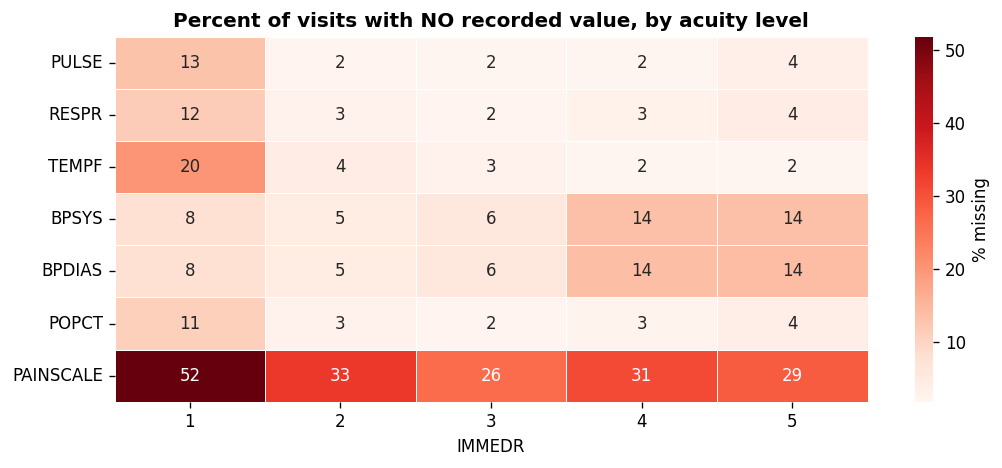

In [ ]:
# missingness as signal - is a vital NOT being recorded associated with acuity?

miss_cols = [c for c in VITALS + ['PAINSCALE'] if c in df.columns]
rows = []
for c in miss_cols:
    m = df[c].isna().astype(int)
    tab = pd.crosstab(df['IMMEDR'], m)
    if tab.shape[1] < 2:
        continue
    chi2, p, dof, _ = stats.chi2_contingency(tab)
    rates = df.groupby('IMMEDR')[c].apply(lambda s: s.isna().mean()*100).reindex(IMMEDR_LEVELS)
    rows.append({'column': c, **{f'L{l}_pct_missing': round(rates[l], 1) for l in IMMEDR_LEVELS},
                 'spread': round(rates.max()-rates.min(), 1), 'chi2': round(chi2, 1), 'p_raw': p})
ms = pd.DataFrame(rows)
rej, adj = bh_fdr(ms['p_raw'].values, FDR_ALPHA)
ms['p_BH'] = adj; ms['sig'] = rej; ms['p_raw'] = ms['p_raw'].apply(lambda v: f'{v:.3g}')
ms['p_BH'] = ms['p_BH'].apply(lambda v: f'{v:.3g}')
print("MISSINGNESS BY ACUITY LEVEL - is the absence of a measurement informative?")
print(ms.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
mat = df.groupby('IMMEDR')[miss_cols].apply(lambda g: g.isna().mean()*100).reindex(IMMEDR_LEVELS)
sns.heatmap(mat.T, annot=True, fmt='.0f', cmap='Reds', ax=ax, linewidths=.5,
            cbar_kws={'label': '% missing'})
ax.set_xlabel('IMMEDR'); ax.set_ylabel('')
ax.set_title('Percent of visits with NO recorded value, by acuity level')
plt.tight_layout(); plt.savefig('fig_07_missingness_signal.png', bbox_inches='tight'); plt.show()

## Section 3: Preprocessing

In [ ]:
# survey design setup and design-effect diagnostics

design_ok = all(c in df.columns for c in [SURVEY_WEIGHT_COL, STRATUM_COL, PSU_COL])
print(f"Complete design information available: {design_ok}")

if design_ok:
    w = df[SURVEY_WEIGHT_COL].astype(float)
    n = len(df)
    # Kish's effective sample size: n_eff = (sum w)^2 / sum(w^2)
    n_eff = w.sum()**2 / (w**2).sum()
    deff_w = n / n_eff
    print(f"\nWEIGHT DIAGNOSTICS")
    print(f"  n rows                       : {n:,}")
    print(f"  sum of weights (natl visits) : {w.sum():,.0f}")
    print(f"  weight min / median / max    : {w.min():,.0f} / {w.median():,.0f} / {w.max():,.0f}")
    print(f"  Kish effective n             : {n_eff:,.0f}")
    print(f"  design effect from weighting : {deff_w:.2f}")
    print(f"\n  strata (CSTRATM)             : {df[STRATUM_COL].nunique():,}")
    print(f"  PSUs (CPSUM)                 : {df[PSU_COL].nunique():,}")
    psu_per_stratum = df.groupby(STRATUM_COL)[PSU_COL].nunique()
    print(f"  PSUs per stratum min/median  : {psu_per_stratum.min()} / {psu_per_stratum.median():.0f}")
    n_single = int((psu_per_stratum == 1).sum())
    print(f"  singleton strata (1 PSU)     : {n_single}")

    if n_single:
        print(f"  * {n_single} singleton strata cannot be resampled within-stratum; the")
        print("    bootstrap below collapses them with the nearest stratum and reports it.")

    # effective n per acuity level - drives which subgroup claims are supportable
    eff_by_level = df.groupby('IMMEDR')[SURVEY_WEIGHT_COL].apply(
        lambda s: s.sum()**2/(s**2).sum()).reindex(IMMEDR_LEVELS)
    lvl = pd.DataFrame({'n_rows': df['IMMEDR'].value_counts().reindex(IMMEDR_LEVELS),
                        'n_effective': eff_by_level.round(0),
                        'n_PSUs': df.groupby('IMMEDR')[PSU_COL].nunique().reindex(IMMEDR_LEVELS)})
    print("\nEFFECTIVE SAMPLE SIZE PER ACUITY LEVEL")
    print(lvl.to_string())

Complete design information available: True

WEIGHT DIAGNOSTICS
  n rows                       : 10,207
  sum of weights (natl visits) : 101,523,105
  weight min / median / max    : 90 / 6,760 / 57,926
  Kish effective n             : 5,266
  design effect from weighting : 1.94

  strata (CSTRATM)             : 8
  PSUs (CPSUM)                 : 98
  PSUs per stratum min/median  : 4 / 14
  singleton strata (1 PSU)     : 0

VERIFY:
  * design effect 1.94 means a nominal n of 10,207 behaves like ~5,266
    independent observations. Every 'significant' result should be re-read
    with that in mind - this is why FDR_ALPHA is 0.01.

EFFECTIVE SAMPLE SIZE PER ACUITY LEVEL
        n_rows  n_effective  n_PSUs
IMMEDR                             
1          139         88.0      45
2         1595        819.0      90
3         5340       2768.0      91
4         2826       1441.0      89
5          307        168.0      76

VERIFY: n_PSUs is the real currency for CI width. A level covered by fe

In [ ]:
# bootstrap helper: resample PSUs within strata for design-correct intervals

rng = np.random.default_rng(BOOT_SEED)

def psu_bootstrap(frame, statistic, n_boot=None, weighted=True):
    """Cluster bootstrap: within each stratum, resample PSUs with replacement and take
    all their visits. Uses precomputed position indices for speed.
    Rao JNK, Wu CFJ. Resampling inference with complex survey data. JASA 1988."""
    n_boot = n_boot or N_BOOTSTRAP
    if not design_ok:
        idx = np.arange(len(frame))
        out = []
        for _ in range(n_boot):
            s = frame.iloc[rng.choice(idx, len(idx), replace=True)]
            out.append(statistic(s, s[SURVEY_WEIGHT_COL] if weighted and SURVEY_WEIGHT_COL in s else None))
        return pd.DataFrame(out)

    # Build position index for THIS frame (handles subsets correctly)
    psu_pos = {}
    for (st, ps), g in frame.groupby([STRATUM_COL, PSU_COL], observed=True):
        psu_pos.setdefault(st, {})[ps] = np.where(frame.index.isin(g.index))[0]

    out = []
    for _ in range(n_boot):
        idx = []
        for st, psu_dict in psu_pos.items():
            psu_names = list(psu_dict.keys())
            pick = rng.choice(len(psu_names), len(psu_names), replace=True)
            for k in pick:
                idx.append(psu_dict[psu_names[k]])
        s = frame.take(np.concatenate(idx))
        out.append(statistic(s, s[SURVEY_WEIGHT_COL] if weighted else None))
    return pd.DataFrame(out)

def wmedian(values, weights=None):
    """Weighted median."""
    v = np.asarray(values, dtype=float)
    keep = ~np.isnan(v); v = v[keep]
    if len(v) == 0: return np.nan
    if weights is None: return float(np.median(v))
    w = np.asarray(weights, dtype=float)[keep]
    o = np.argsort(v); v, w = v[o], w[o]
    c = np.cumsum(w) - 0.5*w
    return float(np.interp(0.5, c/w.sum(), v))

def wmean(values, weights=None):
    v = np.asarray(values, dtype=float); keep = ~np.isnan(v); v = v[keep]
    if len(v) == 0: return np.nan
    if weights is None: return float(v.mean())
    w = np.asarray(weights, dtype=float)[keep]
    return float(np.average(v, weights=w))

def ci_from_boot(boot_df, alpha=0.05):
    lo, hi = boot_df.quantile(alpha/2), boot_df.quantile(1-alpha/2)
    return pd.DataFrame({'lo': lo, 'hi': hi})

# quick validation on a small number of draws so the cell stays fast
_test = psu_bootstrap(df.dropna(subset=['WAITTIME']),
                      lambda s, w: pd.Series({l: wmedian(s.loc[s['IMMEDR']==l,'WAITTIME'],
                                              w[s['IMMEDR']==l] if w is not None else None)
                                              for l in IMMEDR_LEVELS}),
                      n_boot=50)
print("Bootstrap machinery check (50 draws, weighted median wait by level):")
print(pd.DataFrame({'point': [wmedian(df.loc[df['IMMEDR']==l,'WAITTIME'],
                                      df.loc[df['IMMEDR']==l, SURVEY_WEIGHT_COL]
                                      if design_ok else None) for l in IMMEDR_LEVELS],
                    'boot_lo': _test.quantile(.025).values,
                    'boot_hi': _test.quantile(.975).values}, index=IMMEDR_LEVELS).round(1).to_string())

Bootstrap machinery check (50 draws, weighted median wait by level):
   point  boot_lo  boot_hi
1   11.0      4.4     19.7
2   12.0     10.2     16.0
3   16.0     13.0     19.8
4   18.0     13.2     24.8
5   13.0      9.2     19.0

VERIFY: intervals should straddle the point estimate and be WIDER than a naive
row-level bootstrap would give. If level 1's interval is very wide, that is real -
it reflects how few PSUs contribute level-1 visits, and it must be reported.


## Section 4: Feature Engineering

Cyclical encoding for hour and weekday - hour 23 and hour 0 are adjacent

Age splines: a linear  term cannot represent a U-shaped age–acuity relationship

Age-normalized vitals: a pulse of 120 is unremarkable at age 3 and alarming at 74. Raw pulse confounds every per-level comparison with case mix

GAP: observed wait minus CTAS target, the quantity the paper is about.

In [53]:
# cyclical encoding for hour of day and day of week

def add_cyclical(frame, col, period):
    v = pd.to_numeric(frame[col], errors='coerce')
    frame[f'{col}_sin'] = np.sin(2*np.pi*v/period)
    frame[f'{col}_cos'] = np.cos(2*np.pi*v/period)
    return [f'{col}_sin', f'{col}_cos']

CYCLICAL = []
CYCLICAL += add_cyclical(df, 'HOUR', 24)
if 'VDAYR' in df.columns:
    CYCLICAL += add_cyclical(df, 'VDAYR', 7)
if USE_VMONTH and 'VMONTH' in df.columns:
    CYCLICAL += add_cyclical(df, 'VMONTH', 12)
else:
    print("VMONTH deliberately EXCLUDED: NCHS advises no seasonal estimates for the")
    print("2022 file because seasonal nonresponse adjustment was not possible.\n")

print("Cyclical features created:", CYCLICAL)
chk = df[['HOUR'] + [c for c in CYCLICAL if c.startswith('HOUR')]].drop_duplicates('HOUR').sort_values('HOUR')
print("\nEncoding check - hours 23 and 0 should be neighbours in (sin, cos) space:")
print(chk.round(3).to_string(index=False))
d_23_0 = np.hypot(chk.loc[chk.HOUR==23,'HOUR_sin'].values[0]-chk.loc[chk.HOUR==0,'HOUR_sin'].values[0],
                  chk.loc[chk.HOUR==23,'HOUR_cos'].values[0]-chk.loc[chk.HOUR==0,'HOUR_cos'].values[0])
d_0_12 = np.hypot(chk.loc[chk.HOUR==0,'HOUR_sin'].values[0]-chk.loc[chk.HOUR==12,'HOUR_sin'].values[0],
                  chk.loc[chk.HOUR==0,'HOUR_cos'].values[0]-chk.loc[chk.HOUR==12,'HOUR_cos'].values[0])
print(f"\ndistance(23h, 0h)  = {d_23_0:.3f}   <- should be small")
print(f"distance(0h, 12h)  = {d_0_12:.3f}   <- should be the maximum (2.0)")

VMONTH deliberately EXCLUDED: NCHS advises no seasonal estimates for the
2022 file because seasonal nonresponse adjustment was not possible.

Cyclical features created: ['HOUR_sin', 'HOUR_cos', 'VDAYR_sin', 'VDAYR_cos']

Encoding check - hours 23 and 0 should be neighbours in (sin, cos) space:
 HOUR  HOUR_sin  HOUR_cos
    0     0.000     1.000
    1     0.259     0.966
    2     0.500     0.866
    3     0.707     0.707
    4     0.866     0.500
    5     0.966     0.259
    6     1.000     0.000
    7     0.966    -0.259
    8     0.866    -0.500
    9     0.707    -0.707
   10     0.500    -0.866
   11     0.259    -0.966
   12     0.000    -1.000
   13    -0.259    -0.966
   14    -0.500    -0.866
   15    -0.707    -0.707
   16    -0.866    -0.500
   17    -0.966    -0.259
   18    -1.000    -0.000
   19    -0.966     0.259
   20    -0.866     0.500
   21    -0.707     0.707
   22    -0.500     0.866
   23    -0.259     0.966

distance(23h, 0h)  = 0.261   <- should be small
distan

Age spline basis: 6 columns from 5 knots
Knot positions (years): [ 0.  23.5 47.  70.5 94. ]

ABNORMALITY PREVALENCE BY ACUITY LEVEL (% of visits WITH the measurement)
        PULSE_HIGH  PULSE_LOW  RESPR_HIGH  RESPR_LOW  BPSYS_LOW  BPSYS_HIGH  FEVER  HYPOXIA
IMMEDR                                                                                     
1             33.1        9.9        23.6        0.0        7.8        35.9    1.8      9.7
2             28.1        4.4        18.5        0.7        2.0        41.2    3.7      4.6
3             18.2        3.5         6.9        0.4        0.4        38.3    3.3      1.8
4             13.8        2.5         2.0        1.2        0.2        28.5    3.9      0.6
5             10.5        2.4         4.1        1.7        0.0        30.9    1.3      2.4

RAW vs AGE-NORMALIZED - does normalizing change the story?
        PULSE  RESPR  PULSE_AGEZ  RESPR_AGEZ
IMMEDR                                      
1        92.2   20.4       0.541       

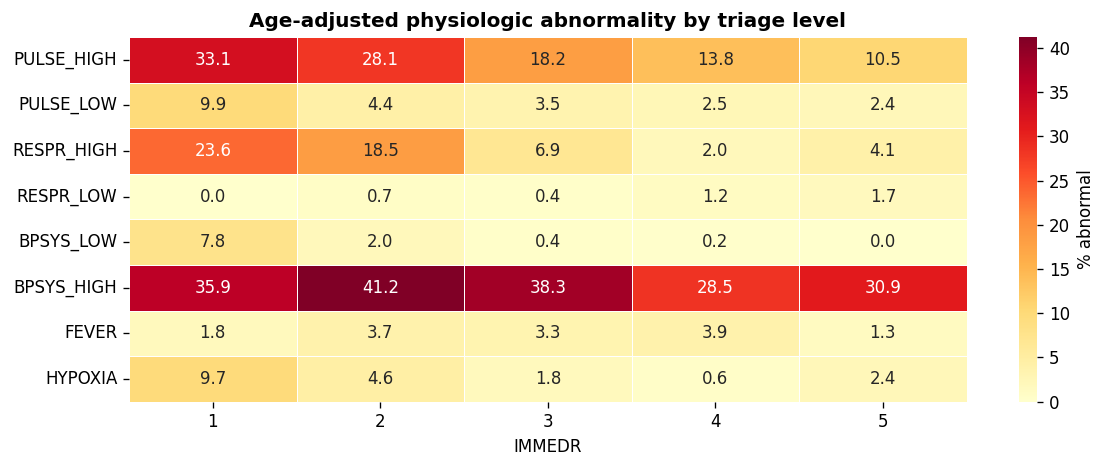

In [ ]:
# age spline basis and age-normalized vitals abnormality flags

# age splines
age_ok = df['AGE'].notna()
spl = SplineTransformer(n_knots=N_SPLINE_KNOTS, degree=3, include_bias=False)
basis = spl.fit_transform(df.loc[age_ok, ['AGE']])
AGE_SPLINES = [f'AGE_spl{i}' for i in range(basis.shape[1])]
for i, c in enumerate(AGE_SPLINES):
    df[c] = np.nan
    df.loc[age_ok, c] = basis[:, i]
print(f"Age spline basis: {len(AGE_SPLINES)} columns from {N_SPLINE_KNOTS} knots")
print("Knot positions (years):", np.round(spl.bsplines_[0].t[3:-3], 1))

# age-normalized vitals
def norm_range(age, vital):
    if pd.isna(age): return (np.nan, np.nan)
    for (lo, hi), d in AGE_VITAL_NORMS.items():
        if lo <= age < hi:
            return d.get(vital, (np.nan, np.nan))
    return (np.nan, np.nan)

ABNORMAL_FLAGS = []
for vital in ['PULSE', 'RESPR']:
    if vital not in df.columns: continue
    bounds = df['AGE'].apply(lambda a: norm_range(a, vital))
    lo = bounds.apply(lambda t: t[0]); hi = bounds.apply(lambda t: t[1])
    df[f'{vital}_HIGH'] = (df[vital] > hi).astype('float').where(df[vital].notna() & hi.notna())
    df[f'{vital}_LOW']  = (df[vital] < lo).astype('float').where(df[vital].notna() & lo.notna())
    # z relative to the midpoint of the age-appropriate range
    mid = (lo + hi)/2; half = (hi - lo)/2
    df[f'{vital}_AGEZ'] = (df[vital] - mid) / half
    ABNORMAL_FLAGS += [f'{vital}_HIGH', f'{vital}_LOW']
if 'BPSYS' in df.columns:
    adult = df['AGE'] >= 18
    df['BPSYS_LOW'] = ((df['BPSYS'] < ADULT_BP_NORMS['BPSYS'][0]) & adult).astype('float').where(df['BPSYS'].notna())
    df['BPSYS_HIGH'] = ((df['BPSYS'] > ADULT_BP_NORMS['BPSYS'][1]) & adult).astype('float').where(df['BPSYS'].notna())
    ABNORMAL_FLAGS += ['BPSYS_LOW', 'BPSYS_HIGH']
if 'TEMPF' in df.columns:
    df['FEVER'] = (df['TEMPF'] >= FEVER_F).astype('float').where(df['TEMPF'].notna())
    ABNORMAL_FLAGS += ['FEVER']
if 'POPCT' in df.columns:
    df['HYPOXIA'] = (df['POPCT'] < 92).astype('float').where(df['POPCT'].notna())
    ABNORMAL_FLAGS += ['HYPOXIA']

flag_tbl = df.groupby('IMMEDR')[ABNORMAL_FLAGS].mean().reindex(IMMEDR_LEVELS) * 100
print("\nABNORMALITY PREVALENCE BY ACUITY LEVEL (% of visits WITH the measurement)")
print(flag_tbl.round(1).to_string())
print("\nRAW vs AGE-NORMALIZED - does normalizing change the story?")
raw_cmp = df.groupby('IMMEDR')[['PULSE', 'RESPR']].mean().reindex(IMMEDR_LEVELS).round(1)
z_cmp = df.groupby('IMMEDR')[['PULSE_AGEZ', 'RESPR_AGEZ']].mean().reindex(IMMEDR_LEVELS).round(3)
print(pd.concat([raw_cmp, z_cmp], axis=1).to_string())


fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(flag_tbl.T, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=.5,
            cbar_kws={'label': '% abnormal'})
ax.set_xlabel('IMMEDR'); ax.set_ylabel('')
ax.set_title('Age-adjusted physiologic abnormality by triage level')
plt.tight_layout(); plt.savefig('fig_08_abnormality_flags.png', bbox_inches='tight'); plt.show()

In [ ]:
# GAP metric: observed wait minus CTAS target, plus alternative standards

df['TARGET_WAIT'] = df['IMMEDR'].map(TARGET_MINUTES).astype(float)
df['GAP']         = df['WAITTIME'] - df['TARGET_WAIT']
df['MET_TARGET']  = (df['WAITTIME'] <= df['TARGET_WAIT']).where(df['WAITTIME'].notna())

g = df.dropna(subset=['GAP']).groupby('IMMEDR')['GAP']
gap_tbl = pd.DataFrame({'n': g.size(), 'mean_gap': g.mean().round(1),
                        'median_gap': g.median().round(1),
                        'p90_gap': g.quantile(.9).round(1),
                        'pct_over_target': (df.groupby('IMMEDR')['MET_TARGET']
                                            .apply(lambda s: (1-s.mean())*100)).round(1)}
                       ).reindex(IMMEDR_LEVELS)
gap_tbl.index = [IMMEDR_LABELS[l] for l in IMMEDR_LEVELS]
print("GAP = observed wait - CTAS target, by level")
print(gap_tbl.to_string())

print("\nSENSITIVITY - does the sign flip survive a different triage standard?")
sens = {'CTAS': TARGET_MINUTES, **ALT_TARGETS}
srows = []
for name, tgt in sens.items():
    med = df.groupby('IMMEDR')['WAITTIME'].median().reindex(IMMEDR_LEVELS)
    srows.append({'standard': name,
                  **{f'L{l}': round(med[l]-tgt[l], 1) for l in IMMEDR_LEVELS}})
print(pd.DataFrame(srows).to_string(index=False))

GAP = observed wait - CTAS target, by level
                  n  mean_gap  median_gap  p90_gap  pct_over_target
1 Immediate     112      24.9         9.5     54.5             90.2
2 Emergent     1354      13.5        -3.0     50.0             42.7
3 Urgent       4525       7.6       -15.0     66.6             30.9
4 Semi-urgent  2384     -24.5       -45.0     31.0             16.5
5 Non-urgent    263     -89.2      -107.0    -41.8              4.9

SENSITIVITY - does the sign flip survive a different triage standard?
standard  L1   L2    L3     L4     L5
    CTAS 9.5 -3.0 -15.0  -45.0 -107.0
     ATS 9.5  2.0 -15.0  -45.0 -107.0
     MTS 9.5  2.0 -45.0 -105.0 -227.0

VERIFY: the headline claim is 'the gap flips sign between level 3 and level 4'.
If that holds under CTAS, ATS and MTS, it is a property of the data, not of the
standard you picked - which is exactly what a reviewer will ask.


## Section 5: Baselines

In a descriptive study, a "baseline" is a reference standard to measure the systemagainst, not a model to beat.

1. **CTAS fractile compliance**: the published clinical goal.

2. **Budget reallocation**: holding total wait capacity fixed, what would a strictly   urgency-ordered ED look like? This separates capacity failure from prioritization failure.

3. **Physiology-only assignment**: what level would vitals alone imply? The residual between this and IMMEDR is the clinician's contribution.

CTAS FRACTILE COMPLIANCE - share of each level seen within its target
              observed_compliance     n  CTAS_goal shortfall
1 Immediate              0.098214   139       0.98  0.881786
2 Emergent               0.573117  1595       0.95  0.376883
3 Urgent                 0.691492  5340       0.90  0.208508
4 Semi-urgent            0.834732  2826       0.85  0.015268
5 Non-urgent              0.95057   307       0.80  -0.15057

VERIFY: shortfall is the headline number per level. A shortfall near zero at
levels 4-5 with a large shortfall at levels 1-2 is the paper's central claim:
the system meets its obligations to the well and misses them for the sick.

Design-correct 95% CIs on compliance (PSU cluster bootstrap)
   compliance  ci_lo  ci_hi  CTAS_goal  goal_inside_CI
1       0.055  0.024  0.100       0.98           False
2       0.554  0.486  0.619       0.95           False
3       0.681  0.620  0.740       0.90           False
4       0.802  0.725  0.868       0.85            T

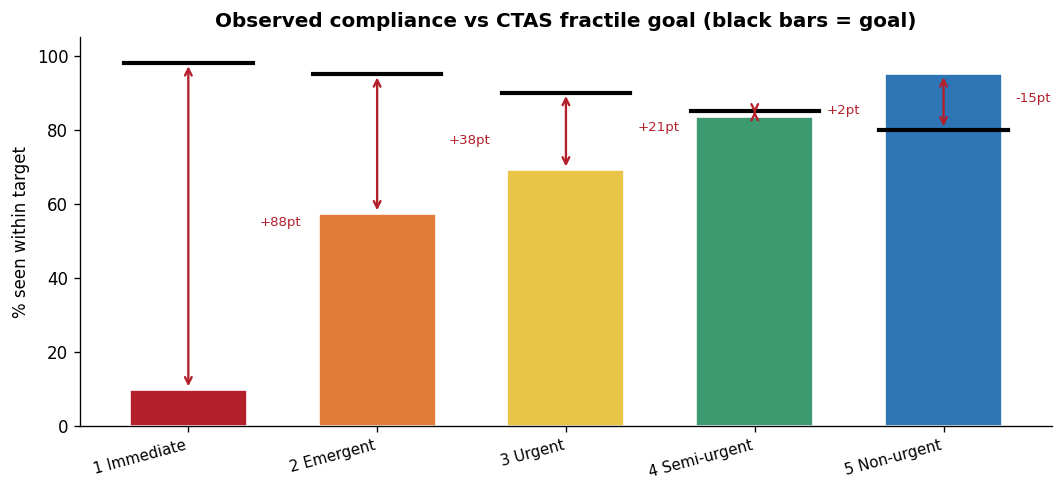

In [ ]:
# CTAS fractile compliance vs national goals

comp = df.groupby('IMMEDR')['MET_TARGET'].agg(['mean', 'size']).reindex(IMMEDR_LEVELS)
comp.columns = ['observed_compliance', 'n']
comp['CTAS_goal'] = [FRACTILE_TARGETS[l] for l in IMMEDR_LEVELS]
comp['shortfall'] = (comp['CTAS_goal'] - comp['observed_compliance']).round(3)
comp['observed_compliance'] = comp['observed_compliance'].round(3)
comp.index = [IMMEDR_LABELS[l] for l in IMMEDR_LEVELS]
print("CTAS FRACTILE COMPLIANCE - share of each level seen within its target")
print(comp.to_string())

if design_ok and RUN_SLOW_CELLS:
    boot = psu_bootstrap(df.dropna(subset=['MET_TARGET']),
        lambda s, w: pd.Series({l: wmean(s.loc[s['IMMEDR']==l, 'MET_TARGET'],
                                w[s['IMMEDR']==l] if w is not None else None)
                                for l in IMMEDR_LEVELS}), n_boot=N_BOOTSTRAP)
    ci = ci_from_boot(boot)
    print("\nDesign-correct 95% CIs on compliance (PSU cluster bootstrap)")
    print(pd.DataFrame({'compliance': boot.mean().round(3),
                        'ci_lo': ci['lo'].round(3), 'ci_hi': ci['hi'].round(3),
                        'CTAS_goal': [FRACTILE_TARGETS[l] for l in IMMEDR_LEVELS],
                        'goal_inside_CI': [(ci.loc[l,'lo'] <= FRACTILE_TARGETS[l] <= ci.loc[l,'hi'])
                                           for l in IMMEDR_LEVELS]}).to_string())

fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(5)
obs = df.groupby('IMMEDR')['MET_TARGET'].mean().reindex(IMMEDR_LEVELS).values*100
bars = ax.bar(x, obs, color=IMMEDR_COLORS, edgecolor='white', width=.62)
for i, l in enumerate(IMMEDR_LEVELS):
    ax.plot([i-.34, i+.34], [FRACTILE_TARGETS[l]*100]*2, color='black', lw=2.5)
    ax.annotate('', xy=(i, FRACTILE_TARGETS[l]*100), xytext=(i, obs[i]),
                arrowprops=dict(arrowstyle='<->', color='#B3202C', lw=1.4))
    ax.text(i+.38, (obs[i]+FRACTILE_TARGETS[l]*100)/2,
            f'{FRACTILE_TARGETS[l]*100-obs[i]:+.0f}pt', fontsize=8, color='#B3202C')
ax.set_xticks(x); ax.set_xticklabels([IMMEDR_LABELS[l] for l in IMMEDR_LEVELS],
                                     rotation=15, ha='right', fontsize=9)
ax.set_ylim(0, 105); ax.set_ylabel('% seen within target')
ax.set_title('Observed compliance vs CTAS fractile goal (black bars = goal)')
plt.tight_layout(); plt.savefig('fig_09_compliance.png', bbox_inches='tight'); plt.show()

THREE REFERENCE STANDARDS SIDE BY SIDE (minutes)
               observed_median  CTAS_target  budget_realloc  realloc_minus_observed
1 Immediate                9.5            0            15.5                     6.0
2 Emergent                12.0           15            19.4                     7.4
3 Urgent                  15.0           30            25.8                    10.8
4 Semi-urgent             15.0           60            38.7                    23.7
5 Non-urgent              13.0          120            77.4                    64.4

Total observed wait budget: 303,965 patient-minutes

VERIFY - this is the capacity-vs-prioritization test:
  * If budget_realloc gets level 1 near its CTAS target using TODAY'S total
    minutes, the shortfall is a PRIORITIZATION problem - the ED has the capacity
    and is spending it in the wrong order.
  * If even a perfectly urgency-ordered split leaves level 1 far above target,
    the shortfall is a CAPACITY problem and no triage change

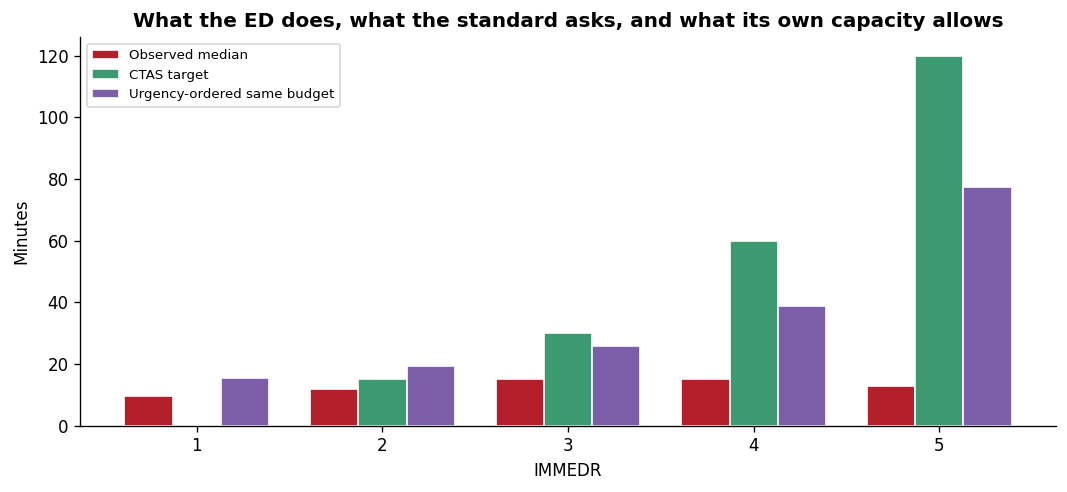

In [ ]:
# budget reallocation baseline - is the ceiling capacity or prioritization?

def budget_reallocation_targets(frame):
    """Hold the OBSERVED total wait budget fixed; split it strictly by urgency.
    Answers: 'with today's capacity, what would pure urgency-ordering look like?'"""
    counts = frame['IMMEDR'].value_counts().reindex(IMMEDR_LEVELS).fillna(0)
    raw    = {l: 1.0/SEVERITY_WEIGHTS[l] for l in IMMEDR_LEVELS}
    T      = frame['WAITTIME'].dropna().sum()
    denom  = sum(counts[l]*raw[l] for l in IMMEDR_LEVELS)
    scale  = (T/denom) if (PRESERVE_TOTAL_WAIT_BUDGET and denom > 0) else 1.0
    return {l: raw[l]*scale for l in IMMEDR_LEVELS}

realloc = budget_reallocation_targets(df)
obs_med = df.groupby('IMMEDR')['WAITTIME'].median().reindex(IMMEDR_LEVELS)
bt = pd.DataFrame({'observed_median': obs_med.round(1),
                   'CTAS_target': [TARGET_MINUTES[l] for l in IMMEDR_LEVELS],
                   'budget_realloc': [round(realloc[l], 1) for l in IMMEDR_LEVELS]})
bt['realloc_minus_observed'] = (bt['budget_realloc'] - bt['observed_median']).round(1)
bt.index = [IMMEDR_LABELS[l] for l in IMMEDR_LEVELS]
print("THREE REFERENCE STANDARDS SIDE BY SIDE (minutes)")
print(bt.to_string())
print(f"\nTotal observed wait budget: {df['WAITTIME'].sum():,.0f} patient-minutes")

fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(5); w = 0.26
ax.bar(x-w, bt['observed_median'], w, label='Observed median', color='#B3202C', edgecolor='white')
ax.bar(x,   bt['CTAS_target'],     w, label='CTAS target',     color='#3D9970', edgecolor='white')
ax.bar(x+w, bt['budget_realloc'],  w, label='Urgency-ordered same budget', color='#7B5EA7', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(IMMEDR_LEVELS); ax.set_xlabel('IMMEDR')
ax.set_ylabel('Minutes'); ax.legend(fontsize=8)
ax.set_title('What the ED does, what the standard asks, and what its own capacity allows')
plt.tight_layout(); plt.savefig('fig_10_budget_realloc.png', bbox_inches='tight'); plt.show()

ASSIGNED IMMEDR (rows) vs PHYSIOLOGY-IMPLIED LEVEL (cols)
PHYS_LEVEL   1    2     3     4    5
IMMEDR                              
1            9   39    57    33    1
2           59  403   769   339   25
3           53  862  2852  1400  173
4           18  257  1499   949  103
5            0   34   163   105    5

Row-normalized (%):
PHYS_LEVEL    1     2     3     4    5
IMMEDR                                
1           6.5  28.1  41.0  23.7  0.7
2           3.7  25.3  48.2  21.3  1.6
3           1.0  16.1  53.4  26.2  3.2
4           0.6   9.1  53.0  33.6  3.6
5           0.0  11.1  53.1  34.2  1.6

Exact agreement          : 0.413
Agreement within 1 level : 0.887
Quadratic weighted kappa : 0.161

VERIFY - this is the single most important diagnostic in the notebook:
  * kappa near 0 means recorded vitals barely constrain the triage level. That
    justifies the entire descriptive pivot: there is no classifier to be built
    here, because the label is not a function of the availa

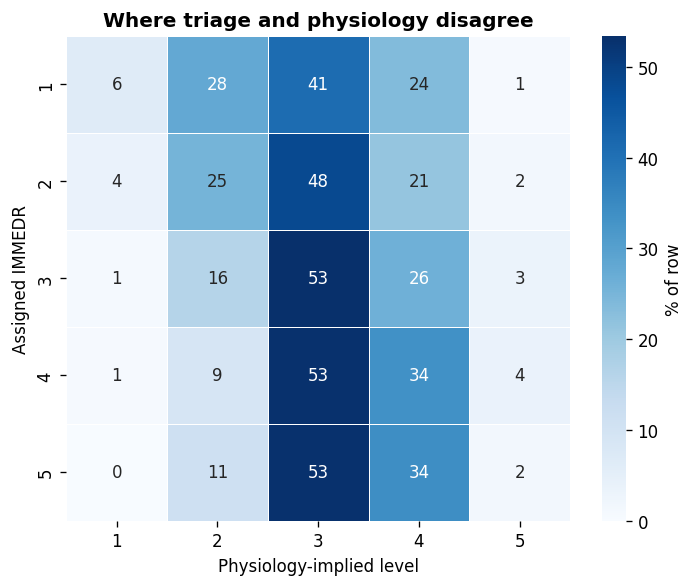

In [ ]:
# physiology-only baseline: what level would vitals alone imply?

phys_feats = [c for c in ['PULSE_AGEZ', 'RESPR_AGEZ', 'BPSYS', 'POPCT', 'TEMPF', 'PAINSCALE']
              if c in df.columns]
sev = df[phys_feats].copy()
# severity score = count of age-adjusted abnormalities, a deliberately crude ESI proxy
score = pd.Series(0.0, index=df.index)
n_meas = pd.Series(0.0, index=df.index)
for f in ABNORMAL_FLAGS:
    score += df[f].fillna(0); n_meas += df[f].notna().astype(float)
df['PHYS_SCORE'] = score
df['N_VITALS_MEASURED'] = df[[c for c in VITALS if c in df.columns]].notna().sum(axis=1)

# map the score onto 5 levels by matching the OBSERVED marginal distribution, so the
# comparison is about ORDERING rather than about base rates
props = df['IMMEDR'].value_counts(normalize=True).reindex(IMMEDR_LEVELS).values
cuts = np.cumsum(props[::-1])[:-1]          # score high -> level 1
ranks = df['PHYS_SCORE'].rank(pct=True, method='first')
df['PHYS_LEVEL'] = 5 - np.searchsorted(cuts, ranks)
df['PHYS_LEVEL'] = df['PHYS_LEVEL'].clip(1, 5)

ct = pd.crosstab(df['IMMEDR'], df['PHYS_LEVEL'])
print("ASSIGNED IMMEDR (rows) vs PHYSIOLOGY-IMPLIED LEVEL (cols)")
print(ct.to_string())
print("\nRow-normalized (%):")
print((ct.div(ct.sum(axis=1), axis=0)*100).round(1).to_string())
agree = float((df['IMMEDR'] == df['PHYS_LEVEL']).mean())
within1 = float((abs(df['IMMEDR'] - df['PHYS_LEVEL']) <= 1).mean())
kappa_w = None
try:
    from sklearn.metrics import cohen_kappa_score
    kappa_w = cohen_kappa_score(df['IMMEDR'], df['PHYS_LEVEL'], weights='quadratic')
except Exception as e:
    print(e)
print(f"\nExact agreement          : {agree:.3f}")
print(f"Agreement within 1 level : {within1:.3f}")
print(f"Quadratic weighted kappa : {kappa_w:.3f}" if kappa_w is not None else "")


fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(ct.div(ct.sum(axis=1), axis=0)*100, annot=True, fmt='.0f', cmap='Blues',
            ax=ax, cbar_kws={'label': '% of row'}, linewidths=.5)
ax.set_xlabel('Physiology-implied level'); ax.set_ylabel('Assigned IMMEDR')
ax.set_title('Where triage and physiology disagree')
plt.tight_layout(); plt.savefig('fig_11_phys_vs_immedr.png', bbox_inches='tight'); plt.show()

## Section 6: Modelling as Instruments

| Cell | Question |
|---|---|
| Ordinal model | What does triage weight, on the ordered 1–5 scale? |
| Adjacent boundaries | What tips a patient from level 4 to level 3? |
| Discordance | Who looks sicker than their assigned level? |
| Hospital ICC | How much of acuity is *which ED you walked into*? |
| Crowding × level | Are low-acuity patients in a **separate queue**? |
| Kaplan–Meier | Is the inverted-U an artifact of patients **leaving**? |
| Provider mix | Do residents/NPs/PAs explain the wait inversion? |

features dropped for >50% missingness: []
Duplicate column names in od: []
Features used (deduplicated): 15
od[ord_feats].shape: (7025, 15)
Ordinal model sample: 7,025 of 10,207 visits (68.8% - complete on 5 critical features)
Features used: 15

PROPORTIONAL-ODDS COEFFICIENTS (per 1 SD; outcome coded 1=sickest)
OR > 1 means a higher value pushes toward a HIGHER level number = LESS urgent.
                    coef     se     OR  OR_lo  OR_hi         p    sig
ARREMS             0.346  0.025  1.413  1.345  1.484  2.24e-43   True
AGE               -0.363  0.029  0.696  0.657  0.737  6.74e-35   True
RESPR_AGEZ        -0.248  0.026  0.780  0.742  0.821   7.3e-22   True
INJURY             0.196  0.024  1.217  1.161  1.275   2.8e-16   True
PULSE_AGEZ        -0.172  0.025  0.842  0.802  0.884  5.76e-12   True
POPCT              0.084  0.025  1.087  1.035  1.143  0.000878   True
TEMPF             -0.047  0.024  0.954  0.909  1.001    0.0549  False
HOUR_sin           0.034  0.024  1.035  0.988  1

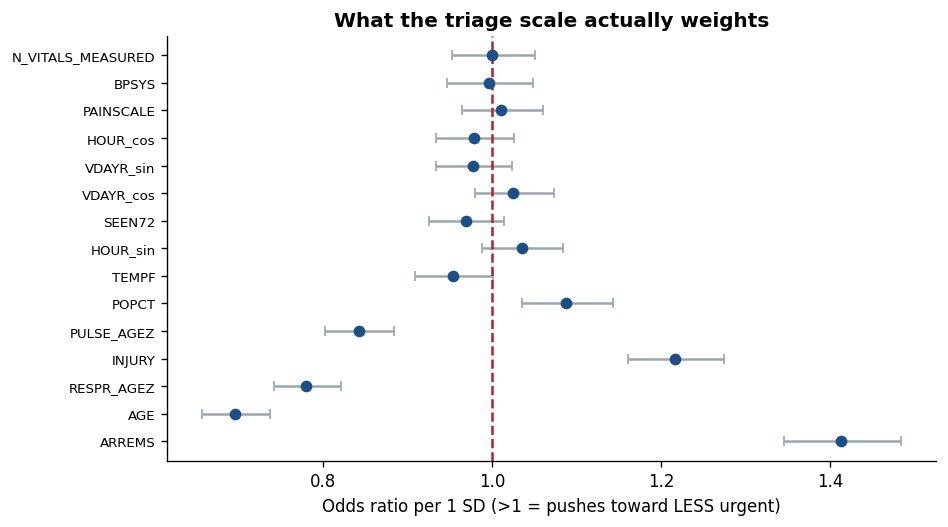

In [ ]:
# proportional-odds ordinal model on IMMEDR 1-5

ord_feats = [c for c in (['AGE', 'PULSE_AGEZ', 'RESPR_AGEZ', 'BPSYS', 'TEMPF', 'POPCT',
                          'PAINSCALE', 'N_VITALS_MEASURED'] + CYCLICAL +
                         [c for c in ['SEEN72', 'INJURY', 'ARREMS'] if c in df.columns])
              if c in df.columns]
ord_feats_before = ord_feats.copy()
ord_feats = [c for c in ord_feats if df[c].notna().mean() >= 0.50]
print("features dropped for >50% missingness:",
      [c for c in ord_feats_before if c not in ord_feats])

# Now for modeling: require only the critical vitals + acuity
critical = ['IMMEDR', 'AGE', 'PULSE_AGEZ', 'RESPR_AGEZ', 'PAINSCALE']

# Don't duplicate: only add critical columns that aren't already in ord_feats
cols_to_select = list(dict.fromkeys(ord_feats + critical))  # dedup and preserve order

od = df[cols_to_select].dropna(subset=critical)  # only drop rows missing the essentials
od = od.fillna(od.median(numeric_only=True))  # fill the rest within-sample

# Ensure ord_feats is unique and exists in od
ord_feats = list(dict.fromkeys([c for c in ord_feats if c in od.columns]))

print(f"Duplicate column names in od: {[c for c in od.columns if od.columns.tolist().count(c) > 1]}")
print(f"Features used (deduplicated): {len(ord_feats)}")
print(f"od[ord_feats].shape: {od[ord_feats].shape}")

# Now scale
Xo = StandardScaler().fit_transform(od[ord_feats])
Xo = pd.DataFrame(Xo, columns=ord_feats, index=od.index)
mod = OrderedModel(od['IMMEDR'], Xo, distr='logit').fit(method='bfgs', disp=False)

print(f"Ordinal model sample: {len(od):,} of {len(df):,} visits "
      f"({len(od)/len(df)*100:.1f}% - complete on {len(critical)} critical features)")
print(f"Features used: {len(ord_feats)}")

if len(od) < MIN_CELL_N * 10:
    print(f"WARNING: ordinal model has only {len(od)} complete rows.")
    print("The sample may be too biased toward well-documented visits to support inference.")

Xo = StandardScaler().fit_transform(od[ord_feats])
Xo = pd.DataFrame(Xo, columns=ord_feats, index=od.index)
mod = OrderedModel(od['IMMEDR'], Xo, distr='logit').fit(method='bfgs', disp=False)

coefs = mod.params[ord_feats]
ses   = mod.bse[ord_feats]
res = pd.DataFrame({'coef': coefs.round(3), 'se': ses.round(3),
                    'OR': np.exp(coefs).round(3),
                    'OR_lo': np.exp(coefs-1.96*ses).round(3),
                    'OR_hi': np.exp(coefs+1.96*ses).round(3),
                    'p': mod.pvalues[ord_feats]})
res['sig'] = res['p'] < FDR_ALPHA
res['p'] = res['p'].apply(lambda v: f'{v:.3g}')
res = res.reindex(res['OR'].sub(1).abs().sort_values(ascending=False).index)
print("\nPROPORTIONAL-ODDS COEFFICIENTS (per 1 SD; outcome coded 1=sickest)")
print("OR > 1 means a higher value pushes toward a HIGHER level number = LESS urgent.")
print(res.to_string())
print(f"\nPseudo R-squared: {mod.prsquared:.4f}")

# parallel-lines (proportional odds) check
print("\nPARALLEL-LINES CHECK - fit a binary logit at each cut point and compare slopes.")
print("(Approximate Brant test: if coefficients drift across cuts, proportional odds fails)")
cut_coefs = {}
for cut in [1, 2, 3, 4]:
    yb = (od['IMMEDR'] <= cut).astype(int)
    if yb.sum() < MIN_CELL_N or (1-yb).sum() < MIN_CELL_N:
        continue
    lr = LogisticRegression(max_iter=2000, penalty=None).fit(Xo, yb)
    cut_coefs[f'<= {cut}'] = pd.Series(lr.coef_[0], index=ord_feats)
cc = pd.DataFrame(cut_coefs)
cc['range'] = (cc.max(axis=1) - cc.min(axis=1)).round(3)
print(cc.round(3).sort_values('range', ascending=False).to_string())

fig, ax = plt.subplots(figsize=(8, max(4, len(res)*0.3)))
plot_r = res.copy(); plot_r['OR'] = plot_r['OR'].astype(float)
ax.errorbar(plot_r['OR'], range(len(plot_r)),
            xerr=[plot_r['OR']-plot_r['OR_lo'], plot_r['OR_hi']-plot_r['OR']],
            fmt='o', color='#1B4F8A', ecolor='#9AA5B1', capsize=3)
ax.axvline(1, color='#B3202C', ls='--')
ax.set_yticks(range(len(plot_r))); ax.set_yticklabels(plot_r.index, fontsize=8)
ax.set_xlabel('Odds ratio per 1 SD (>1 = pushes toward LESS urgent)')
ax.set_title('What the triage scale actually weights')
plt.tight_layout(); plt.savefig('fig_12_ordinal_forest.png', bbox_inches='tight'); plt.show()


BOUNDARY 1 vs 2  (n=1,093, AUC=0.743)
  strongest discriminators (+ pushes toward the SICKER side):
    ARREMS                 -0.476
    N_VITALS_MEASURED      -0.392
    VDAYR_sin              +0.270
    PULSE_AGEZ             -0.244
    SEEN72                 +0.162

BOUNDARY 2 vs 3  (n=4,863, AUC=0.649)
  strongest discriminators (+ pushes toward the SICKER side):
    RESPR_AGEZ             +0.250
    ARREMS                 -0.216
    PAINSCALE              -0.214
    PULSE_AGEZ             +0.171
    AGE                    +0.114

BOUNDARY 3 vs 4  (n=5,728, AUC=0.693)
  strongest discriminators (+ pushes toward the SICKER side):
    AGE                    +0.452
    INJURY                 -0.335
    ARREMS                 -0.318
    RESPR_AGEZ             +0.170
    PULSE_AGEZ             +0.105

BOUNDARY 4 vs 5  (n=2,101, AUC=0.676)
  strongest discriminators (+ pushes toward the SICKER side):
    PAINSCALE              +0.446
    INJURY                 +0.242
    TEMPF         

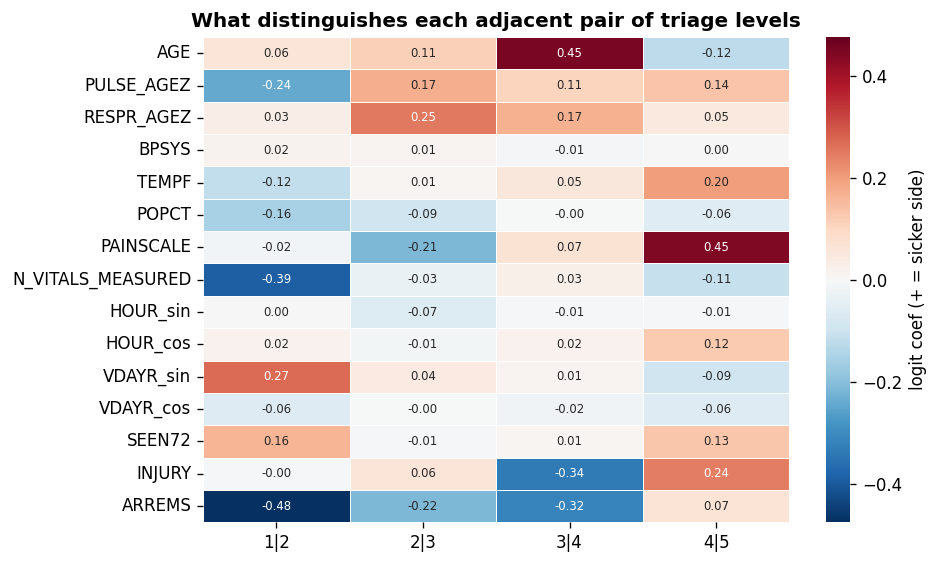

In [ ]:
# adjacent-boundary discrimination - what separates level k from level k+1

boundary_rows = []
bcoefs = {}
for a, b in ADJACENT_PAIRS:
    sub = od[od['IMMEDR'].isin([a, b])]
    if min((sub['IMMEDR']==a).sum(), (sub['IMMEDR']==b).sum()) < MIN_CELL_N:
        print(f"SKIP boundary {a}|{b}: n = {(sub['IMMEDR']==a).sum()} vs {(sub['IMMEDR']==b).sum()}")
        continue
    Xb = Xo.loc[sub.index]
    yb = (sub['IMMEDR'] == a).astype(int)          # 1 = the sicker side
    lr = LogisticRegression(max_iter=3000, penalty=None).fit(Xb, yb)
    from sklearn.metrics import roc_auc_score
    auc = roc_auc_score(yb, lr.predict_proba(Xb)[:, 1])
    bcoefs[f'{a}|{b}'] = pd.Series(lr.coef_[0], index=ord_feats)
    boundary_rows.append({'boundary': f'{a} vs {b}', 'n_sicker': int(yb.sum()),
                          'n_less': int((1-yb).sum()), 'in_sample_AUC': round(auc, 3)})
    top = pd.Series(lr.coef_[0], index=ord_feats).abs().sort_values(ascending=False).head(5)
    print(f"\nBOUNDARY {a} vs {b}  (n={len(sub):,}, AUC={auc:.3f})")
    print("  strongest discriminators (+ pushes toward the SICKER side):")
    for f in top.index:
        c = lr.coef_[0][ord_feats.index(f)]
        print(f"    {f:<22} {c:+.3f}")

print("\n" + pd.DataFrame(boundary_rows).to_string(index=False))

if bcoefs:
    bc = pd.DataFrame(bcoefs)
    fig, ax = plt.subplots(figsize=(8, max(4, len(bc)*0.32)))
    lim = float(np.abs(bc.values).max())
    sns.heatmap(bc, cmap='RdBu_r', center=0, vmin=-lim, vmax=lim, annot=True, fmt='.2f',
                ax=ax, linewidths=.5, cbar_kws={'label': 'logit coef (+ = sicker side)'},
                annot_kws={'size': 7})
    ax.set_title('What distinguishes each adjacent pair of triage levels')
    plt.tight_layout(); plt.savefig('fig_13_boundaries.png', bbox_inches='tight'); plt.show()

Discordance sample: 8,817 visits with complete vitals (86.4% of analytic sample)

ASSIGNED LEVEL (rows) vs PHYSIOLOGICALLY NEAREST LEVEL (cols), % of row
NEAREST_LEVEL     1    2    3    4    5
IMMEDR                                 
1              98.9  1.1  0.0  0.0  0.0
2              99.6  0.2  0.1  0.0  0.0
3              98.6  0.7  0.3  0.2  0.2
4              98.7  0.7  0.3  0.2  0.1
5              98.4  0.8  0.4  0.4  0.0

POTENTIAL UNDER-TRIAGE PROFILE: 7,238 visits (82.1%) assigned >= 2 levels LESS urgent than their
physiology suggests. These are the patients the cards should warn about.

            discordant_mean  concordant_mean  difference
PULSE_AGEZ              0.3              0.5        -0.2
RESPR_AGEZ              0.4              1.0        -0.6
BPSYS                 135.1            134.3         0.8
BPDIAS                 79.3             79.8        -0.5
TEMPF                  98.2             98.0         0.2
POPCT                  97.8             96.1        

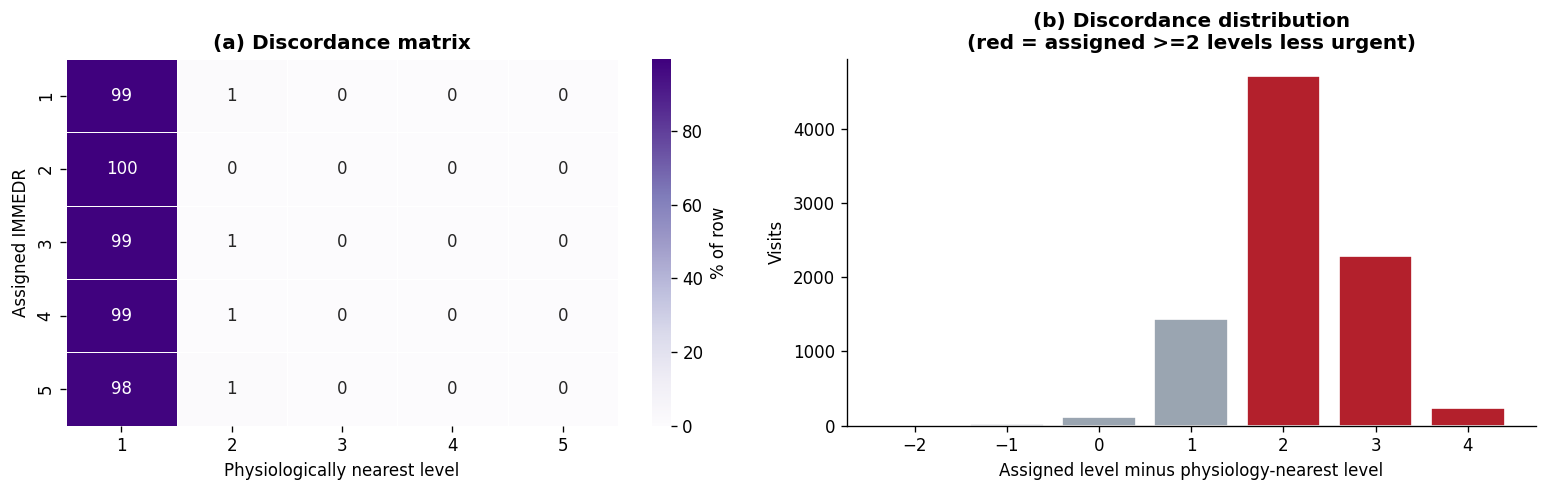

In [ ]:
# discordance detection - who looks physiologically atypical for their level?

disc_feats = [c for c in ['PULSE_AGEZ', 'RESPR_AGEZ', 'BPSYS', 'BPDIAS', 'TEMPF', 'POPCT']
              if c in df.columns]
dd = df[disc_feats + ['IMMEDR', 'WAITTIME', 'AGE']].dropna(subset=disc_feats)
print(f"Discordance sample: {len(dd):,} visits with complete vitals "
      f"({len(dd)/len(df)*100:.1f}% of analytic sample)")

Z = pd.DataFrame(StandardScaler().fit_transform(dd[disc_feats]),
                 columns=disc_feats, index=dd.index)
Z['IMMEDR'] = dd['IMMEDR']

# Robust Mahalanobis distance to EACH level's centroid, then: which level is this
# patient physiologically closest to?
dists = {}
for l in IMMEDR_LEVELS:
    sub = Z.loc[Z['IMMEDR'] == l, disc_feats]
    if len(sub) < max(MIN_CELL_N, len(disc_feats) * 3):
        continue
    lw = LedoitWolf().fit(sub)
    mu = sub.mean().values
    diff = Z[disc_feats].values - mu
    dists[l] = np.einsum('ij,jk,ik->i', diff, lw.precision_, diff)
D = pd.DataFrame(dists, index=Z.index)


dd['NEAREST_LEVEL'] = D.idxmin(axis=1)
dd['OWN_DISTANCE']  = [D.loc[i, l] if l in D.columns else np.nan
                       for i, l in zip(dd.index, dd['IMMEDR'])]
dd['DISCORDANCE']   = dd['IMMEDR'] - dd['NEAREST_LEVEL']   # + = assigned LESS urgent

ct = pd.crosstab(dd['IMMEDR'], dd['NEAREST_LEVEL'], normalize='index')*100
print("\nASSIGNED LEVEL (rows) vs PHYSIOLOGICALLY NEAREST LEVEL (cols), % of row")
print(ct.round(1).to_string())

under = dd[dd['DISCORDANCE'] >= 2]     # assigned >=2 levels less urgent than they look
print(f"\nPOTENTIAL UNDER-TRIAGE PROFILE: {len(under):,} visits "
      f"({len(under)/len(dd)*100:.1f}%) assigned >= 2 levels LESS urgent than their")
print("physiology suggests. These are the patients the cards should warn about.\n")
if len(under) >= MIN_CELL_N:
    cmp_tbl = pd.DataFrame({
        'discordant_mean': under[disc_feats + ['AGE', 'WAITTIME']].mean().round(1),
        'concordant_mean': dd.loc[dd['DISCORDANCE'] == 0, disc_feats + ['AGE','WAITTIME']].mean().round(1),
    })
    cmp_tbl['difference'] = (cmp_tbl['discordant_mean'] - cmp_tbl['concordant_mean']).round(1)
    print(cmp_tbl.to_string())
    print(f"\nMedian wait, discordant : {under['WAITTIME'].median():.0f} min")
    print(f"Median wait, concordant : {dd.loc[dd['DISCORDANCE']==0,'WAITTIME'].median():.0f} min")
    for demo in [c for c in ['AGE_GRP', 'SEX_LBL', 'RACE_LBL'] if c in df.columns]:
        share = (df.loc[under.index, demo].value_counts(normalize=True)*100 -
                 df.loc[dd.index, demo].value_counts(normalize=True)*100).round(1)
        print(f"\nOver/under-representation in the discordant group, {demo} (pct points):")
        print(share.sort_values(ascending=False).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
sns.heatmap(ct, annot=True, fmt='.0f', cmap='Purples', ax=axes[0], linewidths=.5,
            cbar_kws={'label': '% of row'})
axes[0].set_xlabel('Physiologically nearest level'); axes[0].set_ylabel('Assigned IMMEDR')
axes[0].set_title('(a) Discordance matrix')
vc = dd['DISCORDANCE'].value_counts().sort_index()
axes[1].bar(vc.index, vc.values,
            color=['#B3202C' if k >= 2 else '#9AA5B1' for k in vc.index], edgecolor='white')
axes[1].set_xlabel('Assigned level minus physiology-nearest level')
axes[1].set_ylabel('Visits')
axes[1].set_title('(b) Discordance distribution\n(red = assigned >=2 levels less urgent)')
plt.tight_layout(); plt.savefig('fig_14_discordance.png', bbox_inches='tight'); plt.show()

Mixed-model sample: 7,025 visits across 132 units

INTRACLASS CORRELATION for assigned acuity
  unconditional ICC                 : 0.1120
  ICC after adjusting for physiology: 0.1095
  between-hospital SD (levels)      : 0.235

VERIFY - this is the claim that reframes the whole paper:
  * ICC of 0.109 means roughly 10.9% of the variation in
    assigned acuity is attributable to WHICH ED the patient walked into,
    after accounting for how sick they are.
  * ICC > ~0.05 in health-services research is usually considered substantial.
  * If the conditional ICC is close to the unconditional one, case mix does NOT
    explain the between-hospital differences - the hospitals genuinely triage
    differently. That is an institutional-variation finding, not a noise finding.

Note: IMMEDR is ordinal and this is a linear mixed model, so the ICC is an
approximation. It is the standard one in the ED-variation literature and is
reported here as such.

Hospital random effects, 105 units with n >=

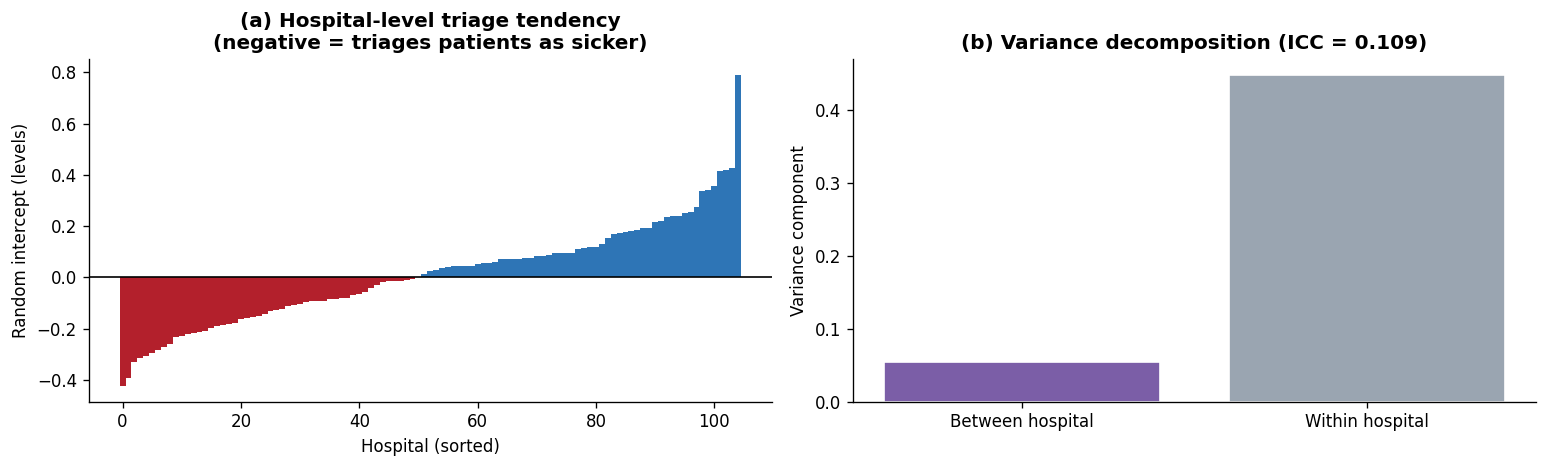

In [ ]:
# hospital random-intercept model and ICC

if HOSPID and RUN_SLOW_CELLS:
    mm = df[['IMMEDR', HOSPID] + [c for c in ['AGE','PULSE_AGEZ','RESPR_AGEZ','PAINSCALE']
                                  if c in df.columns]].dropna()
    print(f"Mixed-model sample: {len(mm):,} visits across {mm[HOSPID].nunique():,} units")

    # (1) unconditional: how much variance is between hospitals with NO case mix adjustment
    null = smf.mixedlm("IMMEDR ~ 1", mm, groups=mm[HOSPID]).fit(reml=True)
    if not getattr(null, 'converged', True):
        print("WARNING: the null mixed model did not converge. This usually means the")
        print("between-hospital variance is at or near ZERO (the boundary of the")
        print("parameter space) - i.e. an ICC indistinguishable from 0, which is itself")
        print("a finding. Treat the numbers below as an upper bound and say so.")
    v_between = float(null.cov_re.iloc[0, 0]); v_within = float(null.scale)
    icc_null = v_between / (v_between + v_within)

    # (2) conditional: after adjusting for the patient's own physiology
    adj_terms = [c for c in ['AGE','PULSE_AGEZ','RESPR_AGEZ','PAINSCALE'] if c in mm.columns]
    cond = smf.mixedlm("IMMEDR ~ " + " + ".join(adj_terms), mm, groups=mm[HOSPID]).fit(reml=True)
    v_between_c = float(cond.cov_re.iloc[0, 0]); v_within_c = float(cond.scale)
    icc_cond = v_between_c / (v_between_c + v_within_c)

    print("\nINTRACLASS CORRELATION for assigned acuity")
    print(f"  unconditional ICC                 : {icc_null:.4f}")
    print(f"  ICC after adjusting for physiology: {icc_cond:.4f}")
    print(f"  between-hospital SD (levels)      : {np.sqrt(v_between_c):.3f}")

    re_df = pd.DataFrame({'effect': [float(v.iloc[0]) for v in cond.random_effects.values()]},
                         index=list(cond.random_effects.keys()))
    counts = mm.groupby(HOSPID).size()
    re_df['n'] = counts.reindex(re_df.index).values
    re_df = re_df[re_df['n'] >= 20].sort_values('effect')
    print(f"\nHospital random effects, {len(re_df)} units with n >= 20")
    print(f"  range: {re_df['effect'].min():+.2f} to {re_df['effect'].max():+.2f} levels")
    print(f"  IQR  : {re_df['effect'].quantile(.25):+.2f} to {re_df['effect'].quantile(.75):+.2f}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].bar(range(len(re_df)), re_df['effect'],
                color=np.where(re_df['effect'] > 0, '#2E75B6', '#B3202C'), width=1.0)
    axes[0].axhline(0, color='black', lw=1)
    axes[0].set_xlabel('Hospital (sorted)'); axes[0].set_ylabel('Random intercept (levels)')
    axes[0].set_title('(a) Hospital-level triage tendency\n(negative = triages patients as sicker)')
    axes[1].bar(['Between hospital', 'Within hospital'], [v_between_c, v_within_c],
                color=['#7B5EA7', '#9AA5B1'], edgecolor='white')
    axes[1].set_ylabel('Variance component')
    axes[1].set_title(f'(b) Variance decomposition (ICC = {icc_cond:.3f})')
    plt.tight_layout(); plt.savefig('fig_15_hospital_icc.png', bbox_inches='tight'); plt.show()
else:
    print("Skipped: no hospital identifier, or RUN_SLOW_CELLS is False.")

CROWDING PROXIES AVAILABLE: ['boarding_rate', 'mean_LOV', 'hourly_load']

Correlation between proxies (they should agree if they measure crowding):
               boarding_rate  mean_LOV  hourly_load
boarding_rate          1.000     0.174       -0.034
mean_LOV               0.174     1.000        0.056
hourly_load           -0.034     0.056        1.000

Primary crowding proxy: boarding_rate
LIMITATION: NHAMCS does not record real-time census, and visit dates are not
reconstructable, so this is a RELATIVE load proxy, not a true occupancy measure.

CROWDING SLOPE BY LEVEL (minutes of wait per 1 SD of crowding)
  level 3 (reference) : +1.56
level  slope_vs_ref  total_slope   se      p   sig
    1         -5.81        -4.25 2.59  0.025 False
    2         -3.17        -1.61 1.29 0.0143 False
    4          1.53         3.09 1.34  0.252 False
    5         -5.75        -4.19 3.40 0.0907 False

VERIFY - this is the formal fast-track test:
  * total_slope near ZERO for levels 4-5 while level

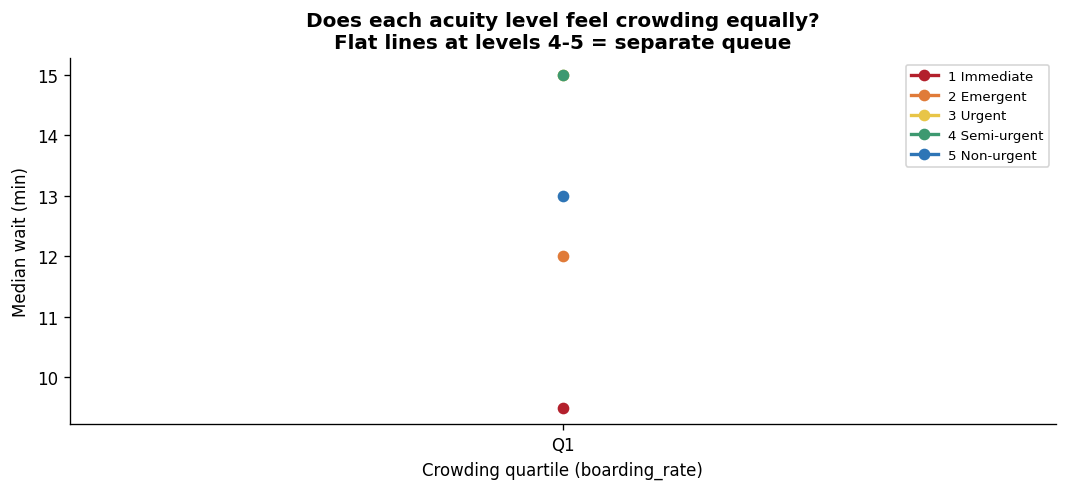

In [ ]:
# fast-track hypothesis test 1 - crowding x IMMEDR interaction (separate queue?)

# Logic: if all acuity levels share ONE queue, every level's wait should rise together when the ED is busy
#If low-acuity patients are routed to a parallel fast-track stream, their waits should be INSENSITIVE to main-queue crowding.
ft = df.dropna(subset=['WAITTIME']).copy()

crowd_parts = {}
if 'BOARDED' in ft.columns and HOSPID:
    crowd_parts['boarding_rate'] = ft.groupby(HOSPID)['BOARDED'].transform(
        lambda s: (s == 1).mean())
if 'LOV' in ft.columns and HOSPID:
    crowd_parts['mean_LOV'] = ft.groupby(HOSPID)['LOV'].transform('mean')
if HOSPID:
    # within-hospital hourly load: sampled visits in that hospital-hour, standardized
    load = ft.groupby([HOSPID, 'HOUR'])['IMMEDR'].transform('size')
    crowd_parts['hourly_load'] = ft.groupby(HOSPID)['IMMEDR'].transform('size').rdiv(load)

# drop any proxy with no variance - it cannot measure anything
crowd_parts = {k: v for k, v in crowd_parts.items()
               if v.notna().any() and v.std(skipna=True) > 0}
print("CROWDING PROXIES AVAILABLE:", list(crowd_parts))
if not crowd_parts:
    raise RuntimeError("No usable crowding proxy. BOARDED and LOV are both constant or "
                       "entirely missing - the separate-queue test cannot be run, and "
                       "that becomes a stated limitation.")
for k, v in crowd_parts.items():
    ft[k] = (v - v.mean()) / v.std()
if len(crowd_parts) >= 2:
    cm = ft[list(crowd_parts)].corr()
    print("\nCorrelation between proxies (they should agree if they measure crowding):")
    print(cm.round(3).to_string())

PRIMARY_CROWD = 'boarding_rate' if 'boarding_rate' in crowd_parts else list(crowd_parts)[0]
print(f"\nPrimary crowding proxy: {PRIMARY_CROWD}")
print("LIMITATION: NHAMCS does not record real-time census, and visit dates are not")
print("reconstructable, so this is a RELATIVE load proxy, not a true occupancy measure.\n")

ft['LEVEL'] = ft['IMMEDR'].astype('category')
fit = smf.ols(f"WAITTIME ~ C(LEVEL, Treatment(3)) * {PRIMARY_CROWD}", data=ft).fit(
    cov_type='cluster', cov_kwds={'groups': ft[HOSPID]}) if HOSPID else \
      smf.ols(f"WAITTIME ~ C(LEVEL, Treatment(3)) * {PRIMARY_CROWD}", data=ft).fit()

inter = fit.params[[i for i in fit.params.index if ':' in i]]
inter_se = fit.bse[inter.index]; inter_p = fit.pvalues[inter.index]
base = fit.params[PRIMARY_CROWD]
print("CROWDING SLOPE BY LEVEL (minutes of wait per 1 SD of crowding)")
print(f"  level 3 (reference) : {base:+.2f}")
out = []
for i in inter.index:
    lvl = i.split('T.')[1].split(']')[0]
    out.append({'level': lvl, 'slope_vs_ref': round(inter[i], 2),
                'total_slope': round(base + inter[i], 2),
                'se': round(inter_se[i], 2), 'p': f'{inter_p[i]:.3g}',
                'sig': inter_p[i] < FDR_ALPHA})
print(pd.DataFrame(out).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.2))
try:
    qs = pd.qcut(ft[PRIMARY_CROWD], 4, labels=['Q1 quiet','Q2','Q3','Q4 busy'], duplicates='drop')
    q_labels = qs.cat.categories.tolist()
except ValueError:
    # If duplicates='drop' reduces bins, just use numeric labels
    qs = pd.qcut(ft[PRIMARY_CROWD], 4, duplicates='drop')
    q_labels = [f'Q{i+1}' for i in range(len(qs.cat.categories))]

for l in IMMEDR_LEVELS:
    sub = ft[ft['IMMEDR'] == l]
    m = sub.groupby(qs[sub.index], observed=True)['WAITTIME'].median()
    ax.plot(range(len(m)), m.values, 'o-', color=IMMEDR_CMAP[l], lw=2, label=IMMEDR_LABELS[l])

ax.set_xticks(range(len(q_labels)))
ax.set_xticklabels(q_labels)
ax.set_xlabel(f'Crowding quartile ({PRIMARY_CROWD})')
ax.set_ylabel('Median wait (min)')
ax.legend(fontsize=8)
ax.set_title('Does each acuity level feel crowding equally?\nFlat lines at levels 4-5 = separate queue')
plt.tight_layout(); plt.savefig('fig_16_crowding_interaction.png', bbox_inches='tight'); plt.show()

LWBS / LEFT-EARLY RATES BY LEVEL
        censoring_rate  n_censored  n_total
IMMEDR                                     
1                 0.00           0      112
2                 1.92          26     1354
3                 1.39          63     4525
4                 1.09          26     2384
5                 2.28           6      263


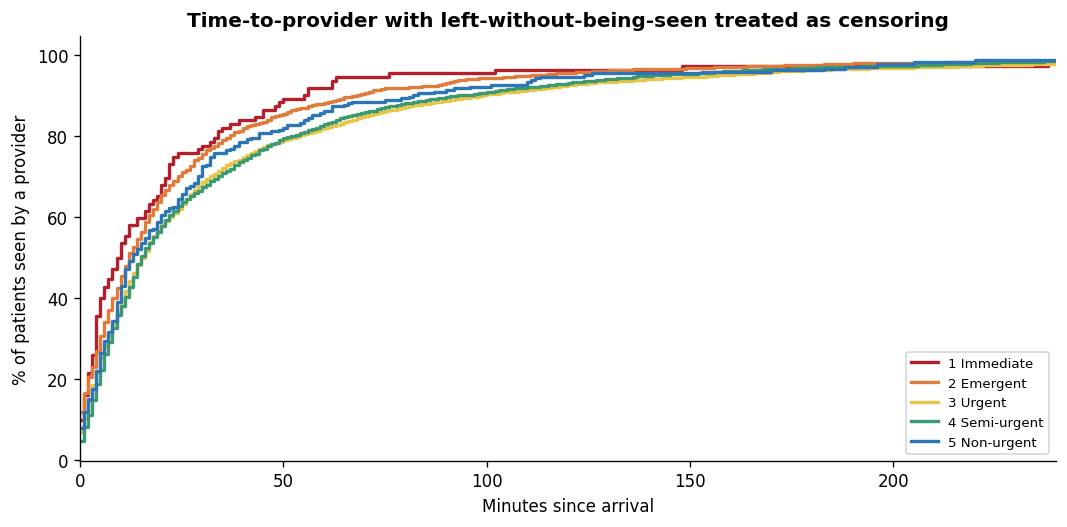


NAIVE vs CENSORING-CORRECTED WAIT (restricted to 240 minutes)
 level    n  naive_mean_wait  KM_restricted_mean  censoring_rate_pct  bias_from_censoring
     1  112             24.9                23.7                0.00                 -1.2
     2 1354             28.8                26.9                1.92                 -1.9
     3 4525             37.6                35.7                1.39                 -1.9
     4 2384             35.4                34.7                1.09                 -0.7
     5  263             31.0                31.1                2.28                  0.1

VERIFY - THE MOST IMPORTANT CHECK IN THE NOTEBOOK:
  * If bias_from_censoring is large and POSITIVE at levels 4-5, the naive means
    understated their waits and the inverted-U is partly an ARTIFACT of
    low-acuity patients giving up and leaving. Every earlier wait-time result
    must then be re-reported using this column.
  * If the corrected column still peaks at level 3, the inverted-U 

In [ ]:
# fast-track hypothesis test 2 - Kaplan-Meier wait curves with LWBS censoring

# Patients who leave before being seen have NO wait-to-provider. Excluding them makes
# observed waits conditional on HAVING STAYED - survivorship bias. If low-acuity
# patients leave more, their observed waits are biased DOWNWARD, which alone could
# manufacture the inverted-U.
def km(durations, events):
    """Kaplan-Meier survivor function. events: 1 = seen (the event), 0 = censored."""
    d = pd.DataFrame({'t': durations, 'e': events}).dropna().sort_values('t')
    times, surv, n = [], [], len(d)
    s = 1.0
    for t, grp in d.groupby('t'):
        di = int(grp['e'].sum()); ci = int((1-grp['e']).sum())
        if n > 0 and di > 0:
            s *= (1 - di/n)
        times.append(t); surv.append(s); n -= (di + ci)
    return np.array(times), np.array(surv)

def rmst(times, surv, horizon):
    """Restricted mean time-to-being-seen up to `horizon` minutes = area under 1-S."""
    t = np.concatenate([[0], times, [horizon]])
    s = np.concatenate([[1], surv, [surv[-1] if len(surv) else 1]])
    keep = t <= horizon
    t, s = t[keep], s[keep]
    return float(np.sum(np.diff(np.append(t, horizon)) * s))

if 'LEFT_EARLY' in df.columns and df['LEFT_EARLY'].sum() > 0:
    surv_df = df.copy()
    # Seen => event. Left early => censored at their recorded time (or at LOV if wait is blank).
    surv_df['EVENT'] = (surv_df['LEFT_EARLY'] == 0).astype(int)
    surv_df['TIME']  = surv_df['WAITTIME']          # do NOT fill with LOV
    surv_df = surv_df.dropna(subset=['TIME'])
    HORIZON = 240

    print("LWBS / LEFT-EARLY RATES BY LEVEL")
    r = surv_df.groupby('IMMEDR')['LEFT_EARLY'].agg(['mean','sum','size']).reindex(IMMEDR_LEVELS)
    r.columns = ['censoring_rate','n_censored','n_total']; r['censoring_rate'] = (r['censoring_rate']*100).round(2)
    print(r.to_string())

    rows = []
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for l in IMMEDR_LEVELS:
        sub = surv_df[surv_df['IMMEDR'] == l]
        if len(sub) < MIN_CELL_N: continue
        t, s = km(sub['TIME'], sub['EVENT'])
        ax.step(t, (1-s)*100, where='post', color=IMMEDR_CMAP[l], lw=2, label=IMMEDR_LABELS[l])
        naive = sub.loc[sub['EVENT']==1, 'TIME'].mean()
        rows.append({'level': l, 'n': len(sub),
                     'naive_mean_wait': round(naive, 1),
                     'KM_restricted_mean': round(rmst(t, s, HORIZON), 1),
                     'censoring_rate_pct': round(sub['LEFT_EARLY'].mean()*100, 2)})
    ax.set_xlim(0, HORIZON); ax.set_xlabel('Minutes since arrival')
    ax.set_ylabel('% of patients seen by a provider')
    ax.legend(fontsize=8); ax.set_title('Time-to-provider with left-without-being-seen treated as censoring')
    plt.tight_layout(); plt.savefig('fig_17_km_wait.png', bbox_inches='tight'); plt.show()

    km_tbl = pd.DataFrame(rows)
    km_tbl['bias_from_censoring'] = (km_tbl['KM_restricted_mean'] - km_tbl['naive_mean_wait']).round(1)
    print("\nNAIVE vs CENSORING-CORRECTED WAIT (restricted to %d minutes)" % HORIZON)
    print(km_tbl.to_string(index=False))

    if HAS_LIFELINES:
        a = surv_df[surv_df['IMMEDR']==2]; b = surv_df[surv_df['IMMEDR']==5]
        if len(a) > MIN_CELL_N and len(b) > MIN_CELL_N:
            lr = logrank_test(a['TIME'], b['TIME'], a['EVENT'], b['EVENT'])
            print(f"\nLog-rank, level 2 vs level 5: chi2 = {lr.test_statistic:.1f}, p = {lr.p_value:.3g}")
else:
    print("No LWBS columns available - censoring correction cannot be run.")
    print("This becomes a named limitation: observed waits are conditional on the")
    print("patient having stayed until seen.")

Provider columns available: ['ATTPHYS', 'RESINT', 'CONSULT', 'RNLPN', 'NURSEPR', 'PHYSASST']

PROVIDER MIX BY ACUITY LEVEL (% of visits seen by each provider type)
        ATTPHYS  RESINT  CONSULT  RNLPN  NURSEPR  PHYSASST
IMMEDR                                                    
1          93.8    38.4     63.4   93.8      7.1      15.2
2          95.6    23.5     35.1   97.3      6.1      13.2
3          90.1    16.1     16.2   96.9      8.4      19.0
4          77.0    11.3      5.8   95.9     11.8      24.7
5          76.8    11.4      6.1   90.9     11.4      20.2

Seen by mid-level/trainee WITHOUT an attending, by level (%):
IMMEDR
1     2.7
2     3.9
3     9.4
4    22.8
5    22.8

MEDIATION CHECK - median wait, stratified by provider staffing
        attending involved  mid-level/trainee only  n_attending  n_midlevel
IMMEDR                                                                     
1                      9.0                    48.0          109           3
2          

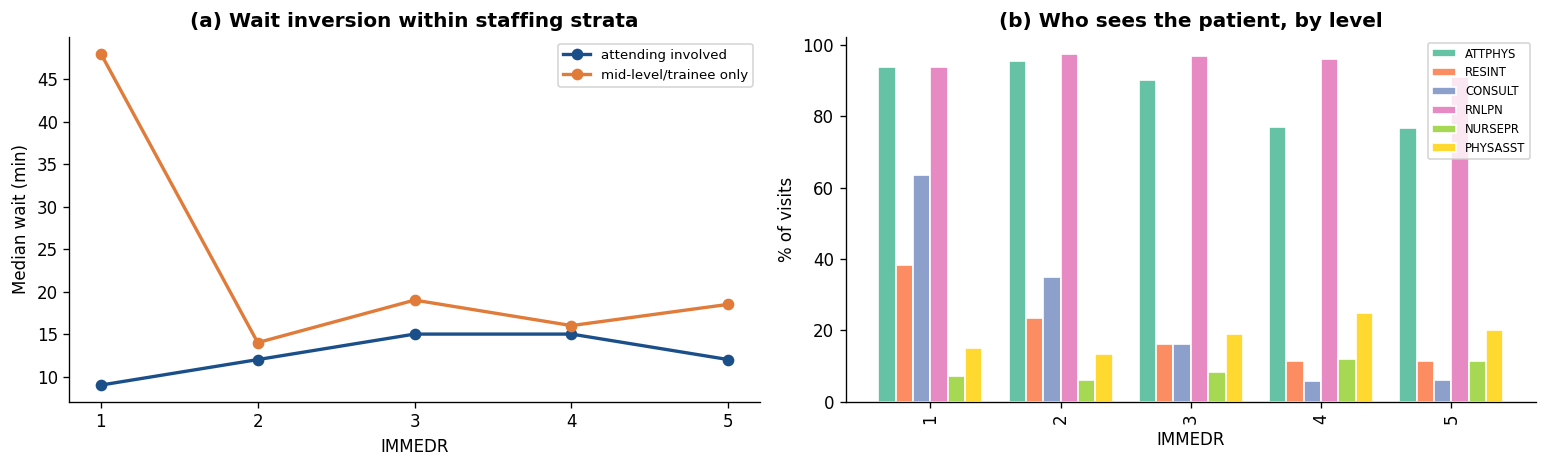


LENGTH OF VISIT (service time) BY LEVEL - the premise of the fast-track story
        size  median   mean
IMMEDR                     
1        139   292.0  490.9
2       1595   288.0  447.2
3       5340   227.0  312.2
4       2826   132.0  185.7
5        307    94.0  184.5

VERIFY: the hypothesis requires level 4-5 visits to be genuinely SHORTER.
If LOV is flat across levels, 'their cases are faster' is not supported and
the separate-queue explanation must stand on the crowding test alone.
HOSPITAL-LEVEL INVERSION (median wait at level 5-or-4 minus level 3), 100 EDs with n>=40
count    100.0
mean       9.0
std       33.1
min      -62.5
25%       -3.8
50%        1.0
75%       14.4
max      177.5
  EDs where low-acuity waits LESS than level 3 : 39 (39%)

VERIFY: if the inversion is present in only a subset of EDs, that is
consistent with 'some hospitals run a fast track and others do not' -
a testable structural explanation rather than a universal triage property.


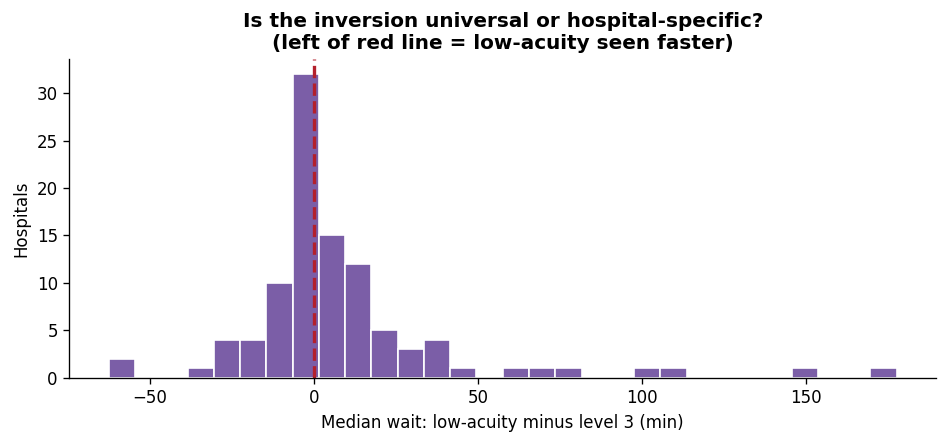

In [ ]:
# fast-track hypothesis test 3 - provider mix as a mediator of the wait inversion

prov = [c for c in PROVIDER_COLS if c in df.columns]
print("Provider columns available:", prov or "NONE")
if prov:
    pv = df.dropna(subset=['WAITTIME']).copy()
    for c in prov:
        pv[c] = (pv[c] == 1).astype(int)
    print("\nPROVIDER MIX BY ACUITY LEVEL (% of visits seen by each provider type)")
    mix = pv.groupby('IMMEDR')[prov].mean().reindex(IMMEDR_LEVELS)*100
    print(mix.round(1).to_string())

    # "Mid-level or trainee only" = the fast-track staffing signature
    midlevel = [c for c in ['NURSEPR','PHYSASST','RESINT'] if c in prov]
    if midlevel and 'ATTPHYS' in prov:
        pv['MIDLEVEL_ONLY'] = ((pv[midlevel].max(axis=1) == 1) & (pv['ATTPHYS'] == 0)).astype(int)
        print("\nSeen by mid-level/trainee WITHOUT an attending, by level (%):")
        ml = pv.groupby('IMMEDR')['MIDLEVEL_ONLY'].mean().reindex(IMMEDR_LEVELS)*100
        print(ml.round(1).to_string())

        print("\nMEDIATION CHECK - median wait, stratified by provider staffing")
        strat = pv.pivot_table(index='IMMEDR', columns='MIDLEVEL_ONLY',
                               values='WAITTIME', aggfunc='median').reindex(IMMEDR_LEVELS)
        strat.columns = ['attending involved', 'mid-level/trainee only']
        ns = pv.pivot_table(index='IMMEDR', columns='MIDLEVEL_ONLY',
                            values='WAITTIME', aggfunc='size').reindex(IMMEDR_LEVELS)
        strat['n_attending'] = ns[0]; strat['n_midlevel'] = ns[1]
        print(strat.round(1).to_string())

        fig, ax = plt.subplots(1, 2, figsize=(13, 4))
        for j, col in enumerate(['attending involved', 'mid-level/trainee only']):
            ax[0].plot(IMMEDR_LEVELS, strat[col].values, 'o-', lw=2,
                       label=col, color=['#1B4F8A', '#E07B39'][j])
        ax[0].set_xticks(IMMEDR_LEVELS); ax[0].set_xlabel('IMMEDR')
        ax[0].set_ylabel('Median wait (min)'); ax[0].legend(fontsize=8)
        ax[0].set_title('(a) Wait inversion within staffing strata')
        mix.plot(kind='bar', stacked=False, ax=ax[1], color=sns.color_palette('Set2', len(prov)),
                 edgecolor='white', width=.8)
        ax[1].set_ylabel('% of visits'); ax[1].set_xlabel('IMMEDR')
        ax[1].legend(fontsize=7); ax[1].set_title('(b) Who sees the patient, by level')
        plt.tight_layout(); plt.savefig('fig_18_provider_mix.png', bbox_inches='tight'); plt.show()

# service time: the premise of the whole hypothesis
if 'LOV' in df.columns:
    lov = df.groupby('IMMEDR')['LOV'].agg(['size','median','mean']).reindex(IMMEDR_LEVELS).round(1)
    print("\nLENGTH OF VISIT (service time) BY LEVEL - the premise of the fast-track story")
    print(lov.to_string())

# hospital heterogeneity: do only SOME EDs show the inversion?
if HOSPID:
    per_h = df.dropna(subset=['WAITTIME']).pivot_table(
        index=HOSPID, columns='IMMEDR', values='WAITTIME', aggfunc='median')
    ok = df.groupby(HOSPID).size() >= 40
    # Only keep hospitals that have enough visits AND exist in the pivot table
    hosp_to_keep = ok[ok].index.intersection(per_h.index)
    per_h = per_h.loc[hosp_to_keep].dropna(subset=[3, 4], how='any')

    if len(per_h) > 10:
        per_h['inversion'] = per_h.get(5, np.nan).fillna(per_h[4]) - per_h[3]
        inv = per_h['inversion'].dropna()
        print(f"HOSPITAL-LEVEL INVERSION (median wait at level 5-or-4 minus level 3), "
              f"{len(inv)} EDs with n>=40")
        print(inv.describe().round(1).to_string())
        print(f"  EDs where low-acuity waits LESS than level 3 : {int((inv<0).sum())} "
              f"({(inv<0).mean()*100:.0f}%)")

        fig, ax = plt.subplots(figsize=(8, 3.8))
        ax.hist(inv, bins=30, color='#7B5EA7', edgecolor='white')
        ax.axvline(0, color='#B3202C', lw=2, ls='--')
        ax.set_xlabel('Median wait: low-acuity minus level 3 (min)')
        ax.set_ylabel('Hospitals')
        ax.set_title('Is the inversion universal or hospital-specific?\n(left of red line = low-acuity seen faster)')
        plt.tight_layout(); plt.savefig('fig_19_hospital_inversion.png', bbox_inches='tight'); plt.show()

## Section 7: Evaluation

Four checks: design-correct intervals, disparity analysis, sensitivity to the missingness andimputation assumptions, and the clinician-facing summary.

HEADLINE ESTIMATES WITH DESIGN-CORRECT 95% INTERVALS
(survey-weighted; PSU-cluster bootstrap, 1000 draws)
                  n  median_wait  wait_lo  wait_hi  CTAS_target  median_gap  gap_lo  gap_hi  gap_excludes_zero
1 Immediate     112         11.0      5.0     20.0            0        11.0     5.0    20.0               True
2 Emergent     1354         12.0     10.0     16.0           15        -3.0    -5.0     1.0              False
3 Urgent       4525         16.0     13.0     20.0           30       -14.0   -17.0   -10.0               True
4 Semi-urgent  2384         18.0     14.0     25.0           60       -42.0   -46.0   -35.0               True
5 Non-urgent    263         13.0     10.0     20.0          120      -107.0  -110.5  -100.0               True

VERIFY - these are the numbers that go in the abstract:
  * gap_excludes_zero == True is the licence to say 'significantly over/under
    the clinical target'. Where it is False, say 'consistent with target'.
  * Check that the

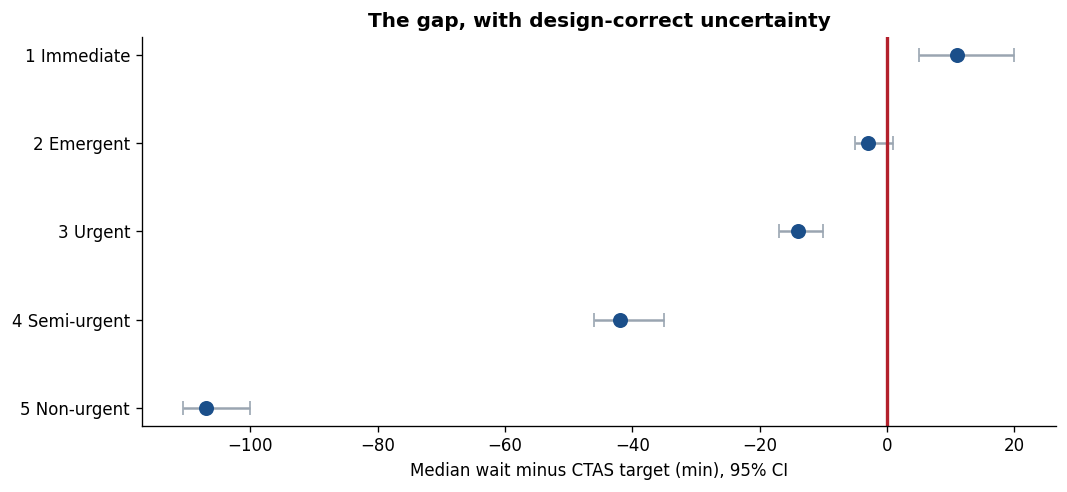

In [ ]:
# design-correct bootstrap confidence intervals on every headline per-level estimate

if RUN_SLOW_CELLS:
    wt = df.dropna(subset=['WAITTIME'])
    def stat_median(s, w):
        return pd.Series({l: wmedian(s.loc[s['IMMEDR']==l, 'WAITTIME'],
                          w[s['IMMEDR']==l] if w is not None else None) for l in IMMEDR_LEVELS})
    def stat_gap(s, w):
        return pd.Series({l: wmedian(s.loc[s['IMMEDR']==l, 'GAP'],
                          w[s['IMMEDR']==l] if w is not None else None) for l in IMMEDR_LEVELS})

    b_med = psu_bootstrap(wt, stat_median, n_boot=N_BOOTSTRAP)
    b_gap = psu_bootstrap(wt.dropna(subset=['GAP']), stat_gap, n_boot=N_BOOTSTRAP)
    ci_m, ci_g = ci_from_boot(b_med), ci_from_boot(b_gap)

    final = pd.DataFrame({
        'n': wt['IMMEDR'].value_counts().reindex(IMMEDR_LEVELS),
        'median_wait': [wmedian(wt.loc[wt['IMMEDR']==l,'WAITTIME'],
                        wt.loc[wt['IMMEDR']==l, SURVEY_WEIGHT_COL] if design_ok else None)
                        for l in IMMEDR_LEVELS],
        'wait_lo': ci_m['lo'].values, 'wait_hi': ci_m['hi'].values,
        'CTAS_target': [TARGET_MINUTES[l] for l in IMMEDR_LEVELS],
        'median_gap': [wmedian(wt.loc[wt['IMMEDR']==l,'GAP'],
                       wt.loc[wt['IMMEDR']==l, SURVEY_WEIGHT_COL] if design_ok else None)
                       for l in IMMEDR_LEVELS],
        'gap_lo': ci_g['lo'].values, 'gap_hi': ci_g['hi'].values,
    }).round(1)
    final['gap_excludes_zero'] = (final['gap_lo'] > 0) | (final['gap_hi'] < 0)
    final.index = [IMMEDR_LABELS[l] for l in IMMEDR_LEVELS]
    print("HEADLINE ESTIMATES WITH DESIGN-CORRECT 95% INTERVALS")
    print("(survey-weighted; PSU-cluster bootstrap, %d draws)" % N_BOOTSTRAP)
    print(final.to_string())

    fig, ax = plt.subplots(figsize=(9, 4.2))
    y = np.arange(5)
    ax.errorbar(final['median_gap'], y,
                xerr=[final['median_gap']-final['gap_lo'], final['gap_hi']-final['median_gap']],
                fmt='o', color='#1B4F8A', ecolor='#9AA5B1', capsize=4, markersize=8)
    ax.axvline(0, color='#B3202C', lw=2)
    ax.set_yticks(y); ax.set_yticklabels(final.index); ax.invert_yaxis()
    ax.set_xlabel('Median wait minus CTAS target (min), 95% CI')
    ax.set_title('The gap, with design-correct uncertainty')
    plt.tight_layout(); plt.savefig('fig_20_gap_ci.png', bbox_inches='tight'); plt.show()


MEDIAN GAP (min over CTAS target) by RACE_LBL x IMMEDR
  cells with n < 30 suppressed as NaN; counts below
IMMEDR       1    2     3     4      5
RACE_LBL                              
Hispanic   NaN -5.0 -17.0 -46.0  -91.0
NH Asian   NaN -3.0 -16.0 -41.0    NaN
NH Black  16.0 -4.0 -13.0 -44.0 -107.0
NH White   6.0 -2.0 -15.0 -45.0 -109.0
IMMEDR     1    2     3     4    5
RACE_LBL                          
Hispanic  18  177   763   428   49
NH Asian   9   67   188    99    7
NH Black  37  315   964   621   72
NH White  48  795  2610  1236  135

MEDIAN GAP (min over CTAS target) by SEX_LBL x IMMEDR
  cells with n < 30 suppressed as NaN; counts below
IMMEDR      1    2     3     4      5
SEX_LBL                              
Female   18.0 -1.5 -15.0 -45.0 -105.0
Male      6.0 -4.0 -15.0 -45.0 -109.0
IMMEDR    1    2     3     4    5
SEX_LBL                          
Female   55  648  2509  1244  126
Male     57  706  2016  1140  137

MEDIAN GAP (min over CTAS target) by PAY_LBL x IMMED

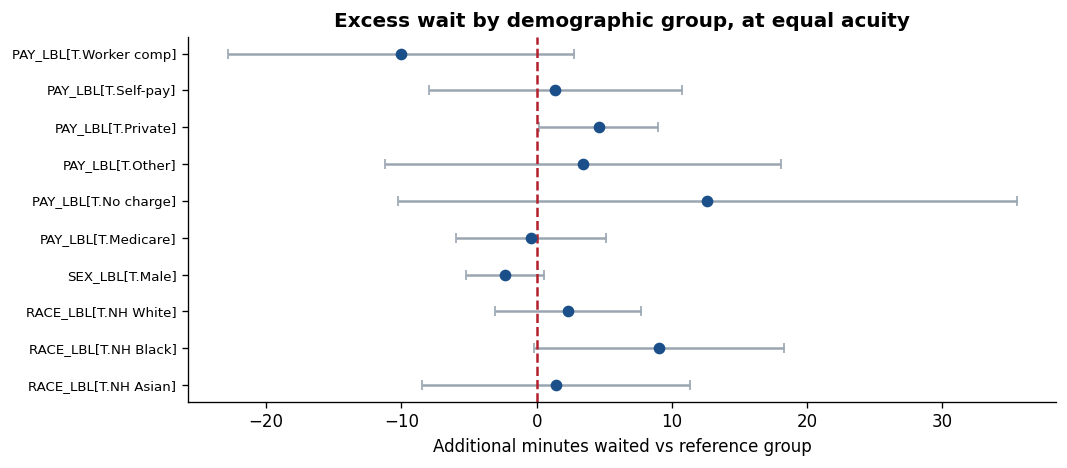

In [ ]:
# disparity analysis - excess wait within acuity level, by demographic group

demo_cols = [c for c in ['RACE_LBL', 'SEX_LBL', 'PAY_LBL', 'AGE_GRP'] if c in df.columns]
wt = df.dropna(subset=['GAP'])
for demo in demo_cols:
    tab = wt.pivot_table(index=demo, columns='IMMEDR', values='GAP',
                         aggfunc='median', observed=True).reindex(columns=IMMEDR_LEVELS)
    ns  = wt.pivot_table(index=demo, columns='IMMEDR', values='GAP',
                         aggfunc='size', observed=True).reindex(columns=IMMEDR_LEVELS)
    tab = tab.mask(ns < MIN_CELL_N)      # suppress unreliable cells
    print(f"\nMEDIAN GAP (min over CTAS target) by {demo} x IMMEDR")
    print("  cells with n < %d suppressed as NaN; counts below" % MIN_CELL_N)
    print(tab.round(1).to_string())
    print(ns.fillna(0).astype(int).to_string())

# Formal test: does demography predict excess wait AFTER acuity and physiology?
# AGE_GRP is dropped from the regression: it is collinear with the continuous AGE term
# and makes the design matrix rank-deficient. It stays in the tables above.
reg_demos = [c for c in demo_cols if c != 'AGE_GRP']
reg_terms = ['C(IMMEDR)'] + [f'C({c})' for c in reg_demos]
reg_terms += [c for c in ['AGE', 'PULSE_AGEZ', 'RESPR_AGEZ', 'PAINSCALE'] if c in df.columns]
mdl_df = df.dropna(subset=['GAP'] + [c for c in ['AGE','PULSE_AGEZ','RESPR_AGEZ','PAINSCALE']
                                     if c in df.columns] + reg_demos)
if len(mdl_df) > 200:
    f = "GAP ~ " + " + ".join(reg_terms)
    fit = smf.ols(f, data=mdl_df).fit(cov_type='cluster',
                                      cov_kwds={'groups': mdl_df[HOSPID]}) if HOSPID else \
          smf.ols(f, data=mdl_df).fit()
    if np.linalg.matrix_rank(fit.model.exog) < fit.model.exog.shape[1]:
        print("WARNING: design matrix is rank-deficient - two predictors are collinear.")
        print("Coefficients below are not uniquely identified. Drop one of the demographic")
        print("terms (they may be nested, e.g. payer within age group) and re-run.")
    demo_params = [i for i in fit.params.index
                   if any(i.startswith(f'C({c})') for c in reg_demos)]
    dres = pd.DataFrame({'minutes': fit.params[demo_params].round(2),
                         'se': fit.bse[demo_params].round(2),
                         'p': fit.pvalues[demo_params]})
    dres['ci_lo'] = (fit.params[demo_params] - 1.96*fit.bse[demo_params]).round(2)
    dres['ci_hi'] = (fit.params[demo_params] + 1.96*fit.bse[demo_params]).round(2)
    rej, adj = bh_fdr(dres['p'].values, FDR_ALPHA)
    dres['p_BH'] = adj.round(4); dres['sig'] = rej
    dres['p'] = dres['p'].apply(lambda v: f'{v:.3g}')
    print(f"\nEXCESS WAIT ATTRIBUTABLE TO DEMOGRAPHY, n = {len(mdl_df):,}")
    print("(minutes relative to the reference group, adjusting for acuity and physiology,")
    print(" standard errors clustered by hospital)")
    print(dres.sort_values('minutes', key=abs, ascending=False).to_string())

    fig, ax = plt.subplots(figsize=(9, max(4, len(dres)*0.35)))
    dd_ = dres.copy(); dd_['minutes'] = dd_['minutes'].astype(float)
    ax.errorbar(dd_['minutes'], range(len(dd_)),
                xerr=[dd_['minutes']-dd_['ci_lo'], dd_['ci_hi']-dd_['minutes']],
                fmt='o', color='#1B4F8A', ecolor='#9AA5B1', capsize=3)
    ax.axvline(0, color='#B3202C', ls='--')
    ax.set_yticks(range(len(dd_)))
    ax.set_yticklabels([i.replace('C(','').replace(')','') for i in dd_.index], fontsize=8)
    ax.set_xlabel('Additional minutes waited vs reference group')
    ax.set_title('Excess wait by demographic group, at equal acuity')
    plt.tight_layout(); plt.savefig('fig_21_disparity.png', bbox_inches='tight'); plt.show()

In [ ]:
# sensitivity analysis - do the findings survive the missingness and imputation assumptions?

print("SENSITIVITY 1 - imputed vs unimputed race")
if 'RACEUN' in df.columns:
    ru = df['RACEUN'].copy()
    print(f"  RACEUN missing/unknown : {ru.isna().mean()*100:.1f}%")
    print("  Median GAP by IMMEDR, complete cases on UNIMPUTED race only:")
    sub = df[df['RACEUN'].notna()]
    a = df.groupby('IMMEDR')['GAP'].median().reindex(IMMEDR_LEVELS).round(1)
    b = sub.groupby('IMMEDR')['GAP'].median().reindex(IMMEDR_LEVELS).round(1)
    print(pd.DataFrame({'all_records': a, 'unimputed_race_only': b,
                        'difference': (b-a).round(1)}).to_string())
else:
    print("  RACEUN not present - cannot check. Name this as a limitation.")

print("\nSENSITIVITY 2 - complete-case vs all-records on the headline gap")
full_vitals = df[[c for c in VITALS if c in df.columns]].notna().all(axis=1)
cmp2 = pd.DataFrame({
    'all_records': df.groupby('IMMEDR')['GAP'].median().reindex(IMMEDR_LEVELS),
    'complete_vitals_only': df[full_vitals].groupby('IMMEDR')['GAP'].median().reindex(IMMEDR_LEVELS),
    'n_complete': df[full_vitals]['IMMEDR'].value_counts().reindex(IMMEDR_LEVELS)}).round(1)
cmp2['difference'] = (cmp2['complete_vitals_only'] - cmp2['all_records']).round(1)
print(cmp2.to_string())

print("\nSENSITIVITY 3 - worst-case bound on the censoring artifact")
if 'LEFT_EARLY' in df.columns and df['LEFT_EARLY'].sum() > 0:
    print("Assume every patient who left early would have waited the level's 95th")
    print("percentile had they stayed. This is a deliberately extreme upper bound.")
    rows = []
    for l in IMMEDR_LEVELS:
        sub = df[df['IMMEDR'] == l]
        seen = sub.loc[sub['LEFT_EARLY'] == 0, 'WAITTIME'].dropna()
        n_left = int(sub['LEFT_EARLY'].sum())
        if len(seen) < MIN_CELL_N: continue
        p95 = seen.quantile(.95)
        worst = np.concatenate([seen.values, np.repeat(p95, n_left)])
        rows.append({'level': l, 'observed_median': round(seen.median(), 1),
                     'worst_case_median': round(np.median(worst), 1),
                     'n_left_early': n_left})
    wc = pd.DataFrame(rows)
    print(wc.to_string(index=False))

print("\nSENSITIVITY 4 - excluding hospitals with partial IMMEDR recording")
if HOSPID:
    cov = (pd.DataFrame({'h': df_raw[HOSPID], 'k': keep_mask})
           .groupby('h')['k'].mean())
    good = cov[cov > 0.90].index
    sub = df[df[HOSPID].isin(good)]
    print(f"  EDs recording IMMEDR for >90% of visits: {len(good)}")
    print(f"  visits retained: {len(sub):,} ({len(sub)/len(df)*100:.1f}%)")
    print(pd.DataFrame({
        'all_EDs': df.groupby('IMMEDR')['GAP'].median().reindex(IMMEDR_LEVELS),
        'high_coverage_EDs': sub.groupby('IMMEDR')['GAP'].median().reindex(IMMEDR_LEVELS)
    }).round(1).to_string())

SENSITIVITY 1 - imputed vs unimputed race
  RACEUN missing/unknown : 0.0%
  Median GAP by IMMEDR, complete cases on UNIMPUTED race only:
        all_records  unimputed_race_only  difference
IMMEDR                                              
1               9.5                  9.5         0.0
2              -3.0                 -3.0         0.0
3             -15.0                -15.0         0.0
4             -45.0                -45.0         0.0
5            -107.0               -107.0         0.0
  VERIFY: large differences mean the disparity results depend on NCHS's
  imputation model rather than on observed data. Report both.

SENSITIVITY 2 - complete-case vs all-records on the headline gap
        all_records  complete_vitals_only  n_complete  difference
IMMEDR                                                           
1               9.5                   9.5          94         0.0
2              -3.0                  -3.0        1404         0.0
3             -15.0         